# BUSA8000_GROUPASM_GROUP15

*Group Members*\
**Thi Van DINH** 48080292\
**Thi Hoang Lan NGUYEN** 48354074\
**Thu Uyen NGUYEN** 48177385\
**Dieu Linh TRAN** 48660108

We acknowledge that we have only used GAITs (e.g., ChatGPT) in drafting and proofreading this assignment, which is permitted in the assignment instructions.

## SECTION 1: DATA CLEANING

### 1. Import Libraries and Dataframe

In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the datasets
df_2012 = pd.read_csv('2012_Data.csv', encoding='ISO-8859-1')
df_2013 = pd.read_csv('2013_Data.csv', encoding='ISO-8859-1')

### 2. Generate Data Overview

In [3]:
print(f"df_2012 has {df_2012.shape[0]} rows and {df_2012.shape[1]} columns.")
print(f"df_2013 has {df_2013.shape[0]} rows and {df_2013.shape[1]} columns.")

df_2012 has 1037205 rows and 41 columns.
df_2013 has 951177 rows and 41 columns.


In [4]:
# View the first few rows of each dataset
print(df_2012.head())
print(df_2013.head())

   accounting_date  fiscal_year  fiscal_month  calendar_year  calendar_month  \
0         20120509         2012            11           2012               5   
1         20120216         2012             8           2012               2   
2         20120509         2012            11           2012               5   
3         20120518         2012            11           2012               5   
4         20120109         2012             7           2012               1   

   calendar_day  company_code customer_code  customer_district_code  \
0             9           101     411800601                     410   
1            16           101     361000403                     300   
2             9           101     361000403                     300   
3            18           101     565540415                     500   
4             9           101     565540415                     500   

                        item_code  ... value_quantity value_price_adjustment  \
0  GENIE8WWW

In [5]:
# Check the data types and for any missing values
print(df_2012.info())
print(df_2013.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1037205 entries, 0 to 1037204
Data columns (total 41 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   accounting_date           1037205 non-null  int64  
 1   fiscal_year               1037205 non-null  int64  
 2   fiscal_month              1037205 non-null  int64  
 3   calendar_year             1037205 non-null  int64  
 4   calendar_month            1037205 non-null  int64  
 5   calendar_day              1037205 non-null  int64  
 6   company_code              1037205 non-null  int64  
 7   customer_code             1037205 non-null  object 
 8   customer_district_code    1037205 non-null  int64  
 9   item_code                 1037205 non-null  object 
 10  business_area_code        1037205 non-null  object 
 11  item_group_code           1037205 non-null  object 
 12  item_class_code           1037205 non-null  object 
 13  item_type                 1

In [6]:
# Get basic statistics
print(df_2012.describe())
print(df_2013.describe())

       accounting_date   fiscal_year  fiscal_month  calendar_year  \
count     1.037205e+06  1.037205e+06  1.037205e+06      1037205.0   
mean      2.012065e+07  2.012482e+03  6.561389e+00         2012.0   
std       3.284399e+02  4.996845e-01  3.589389e+00            0.0   
min       2.012010e+07  2.012000e+03  1.000000e+00         2012.0   
25%       2.012040e+07  2.012000e+03  3.000000e+00         2012.0   
50%       2.012062e+07  2.012000e+03  7.000000e+00         2012.0   
75%       2.012092e+07  2.013000e+03  1.000000e+01         2012.0   
max       2.012123e+07  2.013000e+03  1.200000e+01         2012.0   

       calendar_month  calendar_day  company_code  customer_district_code  \
count    1.037205e+06  1.037205e+06  1.037205e+06            1.037205e+06   
mean     6.348191e+00  1.539114e+01  2.190146e+02            3.784317e+02   
std      3.287332e+00  8.736315e+00  1.715110e+02            1.529866e+02   
min      1.000000e+00  1.000000e+00  1.000000e+02            2.000000e

### 3. Handle Missing Values in 'item_source_class' column

In [7]:
# Drop the item_source_class column from the 2012 dataset
df_2012 = df_2012.drop(columns=['item_source_class'])

# Drop the item_source_class column from the 2013 dataset
df_2013 = df_2013.drop(columns=['item_source_class'])

# Print the shape of the DataFrames to confirm the column was dropped
#print("2012 dataset shape after dropping column:", df_2012.shape)
#print("2013 dataset shape after dropping column:", df_2013.shape)

### 4. Handle Unique Values

In [8]:
# Check unique values in df_2012
# Loop through each column in df_2012 with data type 'object' and print unique values
for col in df_2012.select_dtypes(include='object').columns:
    unique_values = df_2012[col].unique()
    print(f"Column: {col}")
    print(f"Unique values: {unique_values}")
    print(f"Number of unique values: {len(unique_values)}")
    print("-" * 40)
    

Column: customer_code
Unique values: [411800601 361000403 565540415 ... '409200100' '600250100' '467000200']
Number of unique values: 6576
----------------------------------------
Column: item_code
Unique values: ['GENIE8WWWBC                   ' 'GENIE11WWWES                  '
 'GENIE18WCDLES                 ' ... '27099' '27052' '27143']
Number of unique values: 27322
----------------------------------------
Column: business_area_code
Unique values: ['LMP                           ' 'FLD                           '
 'OTH                           ' 'SUR                           '
 'COM                           ' 'DLT                           '
 'TRO                           ' 'URB                           '
 'HLB                           ' 'SAE                           '
 'RWY                           ' 'LCP                           '
 'PEN                           ' 'EXL                           '
 'TAL                           ' '945' '950' '980' '920' '960' '910'
 '93

In [9]:
# Check unique values in df_2013
# Loop through each column in df_2013 with data type 'object' and print unique values
for col in df_2013.select_dtypes(include='object').columns:
    unique_values = df_2013[col].unique()
    print(f"Column: {col}")
    print(f"Unique values: {unique_values}")
    print(f"Number of unique values: {len(unique_values)}")
    print("-" * 40) 

Column: customer_code
Unique values: ['471150112' '277000801' '292314701' ... '467000200' '809599901'
 '455810100']
Number of unique values: 3915
----------------------------------------
Column: item_code
Unique values: ['10311' '10350' '10364' ... 'DT34675139E                   '
 'CRW25459I4XN01                ' '0.90811.00-910                ']
Number of unique values: 23281
----------------------------------------
Column: business_area_code
Unique values: ['COM                           ' 'OTH                           '
 'SUR                           ' 'LMP                           '
 'PEN                           ' '940' 'TRO                           '
 'DLT                           ' 'TAL                           ' '970'
 '999' '980' 'FLD                           '
 'URB                           ' 'IAE                           ' '985'
 'LCP                           ' 'IAI                           ' '920'
 'SAE                           ' 'EXL                          

#### 4.1. Strip the blank space

In [10]:
# Strip the blank space
df_2012 = df_2012.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)
df_2013 = df_2013.apply(lambda col: col.str.strip() if col.dtype == 'object' else col)

#### 4.2. Clean currency column

In [11]:
# Function to clean and process the 'currency' column
def clean_currency_column(df):
    # Step 1: Remove rows where 'currency' is empty or consists only of whitespace
    df = df[df['currency'].str.strip() != '']
    
    # Step 2: Map incorrect currency codes to the correct ones
    currency_mapping = {'AUS': 'AUD'}  # Add more mappings as needed
    df['currency'] = df['currency'].replace(currency_mapping)
    
    # Step 3: Drop rows with invalid currency values (assuming you only want specific valid currencies)
    valid_currencies = ['AUD', 'USD', 'NZD', 'EUR']
    df = df[df['currency'].isin(valid_currencies)]
    
    return df

# Clean the currency column for both datasets
df_2012 = clean_currency_column(df_2012)
df_2013 = clean_currency_column(df_2013)

# Print unique values in currency column in each dataset to confirm the cleaning
print("Unique values in currency column in 2012 dataset:", df_2012['currency'].unique())
print("Unique values in currency column in 2013 dataset:", df_2013['currency'].unique())

Unique values in currency column in 2012 dataset: ['AUD' 'USD' 'NZD' 'EUR']
Unique values in currency column in 2013 dataset: ['AUD' 'NZD' 'USD']


#### 4.3. Exchange currency to AUD

In [12]:
# Exchange currency to AUD in df_2012
# Define the exchange rates for each currency
exchange_rates = {'EUR': 1.2418,'NZD': 0.7823,'USD': 0.9658}

# Apply the exchange rate conversion to value_sales and value_cost
df_2012['value_sales_aud'] = df_2012.apply(
    lambda x: x['value_sales'] * exchange_rates.get(x['currency'], 1), axis=1)

df_2012['value_cost_aud'] = df_2012.apply(
    lambda x: x['value_cost'] * exchange_rates.get(x['currency'], 1), axis=1)

# Drop the original value_sales and value_cost columns
df_2012.drop(['value_sales', 'value_cost'], axis=1, inplace=True)

# # Verify the changes
# print(df_2012.head())

In [13]:
# Exchange currency to AUD in df_2013
# Define the exchange rates for each currency
exchange_rates = {'EUR': 1.3785,'NZD': 0.8497}

# Apply the exchange rate conversion to value_sales and value_cost
df_2013['value_sales_aud'] = df_2013.apply(
    lambda x: x['value_sales'] * exchange_rates.get(x['currency'], 1), axis=1)

df_2013['value_cost_aud'] = df_2013.apply(
    lambda x: x['value_cost'] * exchange_rates.get(x['currency'], 1), axis=1)

# Drop the original value_sales and value_cost columns
df_2013.drop(['value_sales', 'value_cost'], axis=1, inplace=True)

# # Verify the changes
# print(df_2013.head())

#### 4.4. Clean 'customer_district_code' column

In [14]:
# Change customer_district_code to object type for both datasets
df_2012['customer_district_code'] = df_2012['customer_district_code'].astype('object')
df_2013['customer_district_code'] = df_2013['customer_district_code'].astype('object')

# Print unique values in customer_district_code column in each dataset to confirm the cleaning
print("Unique values in customer_district_code column in 2012 dataset:", df_2012['customer_district_code'].unique())
print("Unique values in customer_district_code column in 2013 dataset:", df_2013['customer_district_code'].unique())

Unique values in customer_district_code column in 2012 dataset: [410 300 500 310 400 200 210 720 710 600 510 530 535 540 520 545]
Unique values in customer_district_code column in 2013 dataset: [400 200 510 500 310 300 410 210 600 720 710 535 530 540 520 545 100]


In [15]:
# Filter out rows where 'customer_district_code' is 100 for both datasets
# As value '100' is not described in readme file and could be an input errors
df_2013 = df_2013[df_2013['customer_district_code'] != 100]

#### 4.5. Drop redundant columns

In [16]:
# Drop redundant columns
df_2012 = df_2012.drop(columns=['market_segment','dss_update_time'])
df_2013 = df_2013.drop(columns=['market_segment','dss_update_time'])

# # Verify the changes by display first few rows of the dataset
# df_2012.head(5)
# df_2013.head(5)

#### 4.6. Clean 'business_area_code' column

In [17]:
# Define dictionary to map duplicates to a single value
grouping_dict = {
    'LMP': 'Lamps',
    '970': 'Lamps',
    'FLD': 'Flood',
    '920': 'Flood',
    'OTH': 'Other',
    '999': 'Other',
    'SUR': 'Surface',
    'COM': 'Components',
    'DLT': 'Downlight',
    'TRO': 'Troffer',
    'URB': 'Urban Amenity',
    'HLB': 'Highbay/Lowbay',
    'SAE': 'Stand Alone Emergency',
    'RWY': 'Roadway',
    '930': 'Roadway',
    'LCP': 'Lighting Control',
    'PEN': 'Pendant',
    'EXL': 'Healthcare Lighting',
    'TAL': 'Track & Linear Systems',
    '945': 'Architectural - Exterior',
    '950': 'Commercial',
    '980': 'Trade/Retail - Interior',
    '960': 'Emergency',
    '910': 'Industrial',
    '940': 'Architectural - Interior',
    '985': 'Trade/Retail - Exterior',
    'IAE': 'Inlite Architectural Exterior',
    'IAI': 'Inlite Architectural Interior'
}

# Apply the mapping to the 'business_area_code' column
df_2012['business_area_category'] = df_2012['business_area_code'].map(grouping_dict)
df_2013['business_area_category'] = df_2013['business_area_code'].map(grouping_dict)

# Drop 'business_area_code' column
df_2012 = df_2012.drop(columns=['business_area_code'])
df_2013 = df_2013.drop(columns=['business_area_code'])

# # Print unique values in business_area_code column in each dataset to confirm the cleaning
# print("Unique values in business_area_code column in 2012 dataset:", df_2012['business_area_code'].unique())
# print("Unique values in business_area_code column in 2013 dataset:", df_2013['business_area_code'].unique())

### 5. Convert Date Columns to Time Format

In [18]:
# Define date columns and format
date_columns = ['accounting_date', 'invoice_date', 'order_date']
date_format = '%Y%m%d' 

# Convert date columns for df_2012
for column in date_columns:
    df_2012[column] = pd.to_datetime(df_2012[column].astype(str), format=date_format, errors='coerce')

# Convert date columns for df_2013
for column in date_columns:
    df_2013[column] = pd.to_datetime(df_2013[column].astype(str), format=date_format, errors='coerce')

# # Print the data types to verify conversion
# print("\nData types for df_2012:")
# print(df_2012.dtypes)

# print("\nData types for df_2013:")
# print(df_2013.dtypes)

### 6. Handle Duplicates

In [19]:
#Check for duplicates
duplicates_2012 = df_2012.duplicated().sum()
duplicates_2013 = df_2013.duplicated().sum()

print("Duplicates in 2012 dataset:", duplicates_2012)
print("Duplicates in 2013 dataset:", duplicates_2013)

#Remove duplicates if any
df_2012 = df_2012.drop_duplicates()
df_2013 = df_2013.drop_duplicates()

Duplicates in 2012 dataset: 5085
Duplicates in 2013 dataset: 3686


In [20]:
# Check the number of columns and rows
total_rows, total_columns = df_2012.shape
print(f"Total columns of 2012 dataset: {total_columns}")
print(f"Total rows of 2012 dataset: {total_rows}")

# Check the number of columns and rows
total_rows, total_columns = df_2013.shape
print(f"Total columns of 2013 dataset: {total_columns}")
print(f"Total rows of 2013 dataset: {total_rows}")

Total columns of 2012 dataset: 38
Total rows of 2012 dataset: 1032119
Total columns of 2013 dataset: 38
Total rows of 2013 dataset: 947484


### 7. Histogram

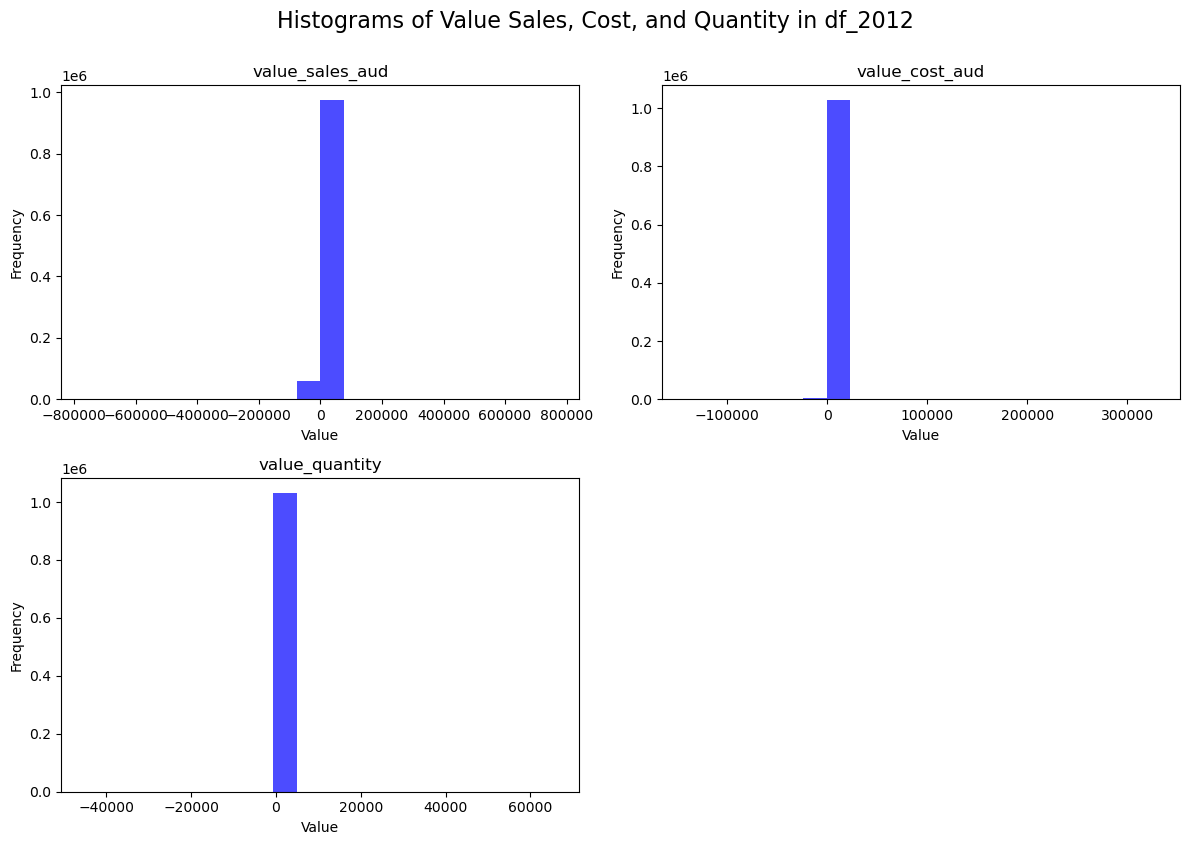

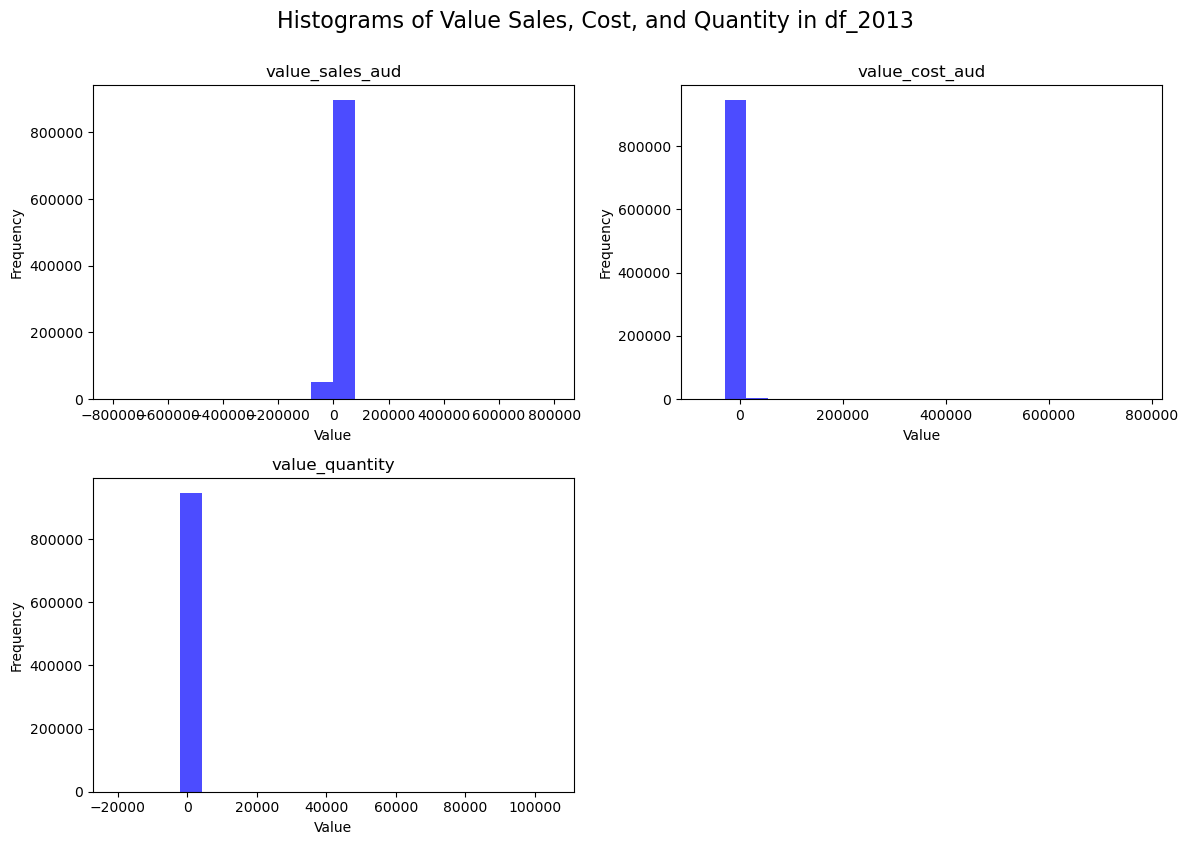

In [21]:
import matplotlib.pyplot as plt

# List of columns to plot histograms for
columns_to_plot = ['value_sales_aud', 'value_cost_aud', 'value_quantity']

# Function to plot histograms for specified columns
def plot_histograms(df, columns, title):
    plt.figure(figsize=(12, 8))  # Set figure size
    num_columns = len(columns)
    
    for i, column in enumerate(columns):
        plt.subplot((num_columns // 2) + (num_columns % 2), 2, i + 1)  # Create a grid of 2 columns
        plt.hist(df[column], bins=20, color='blue', alpha=0.7)  # Set number of bins to 20
        plt.title(column)
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        
    plt.tight_layout()
    plt.suptitle(title, fontsize=16, y=1.05)  # Adjust y to fit the title
    plt.show()

# Plot histograms for df_2012
plot_histograms(df_2012, columns_to_plot, 'Histograms of Value Sales, Cost, and Quantity in df_2012')

# Plot histograms for df_2013
plot_histograms(df_2013, columns_to_plot, 'Histograms of Value Sales, Cost, and Quantity in df_2013')

### 8. Outliers

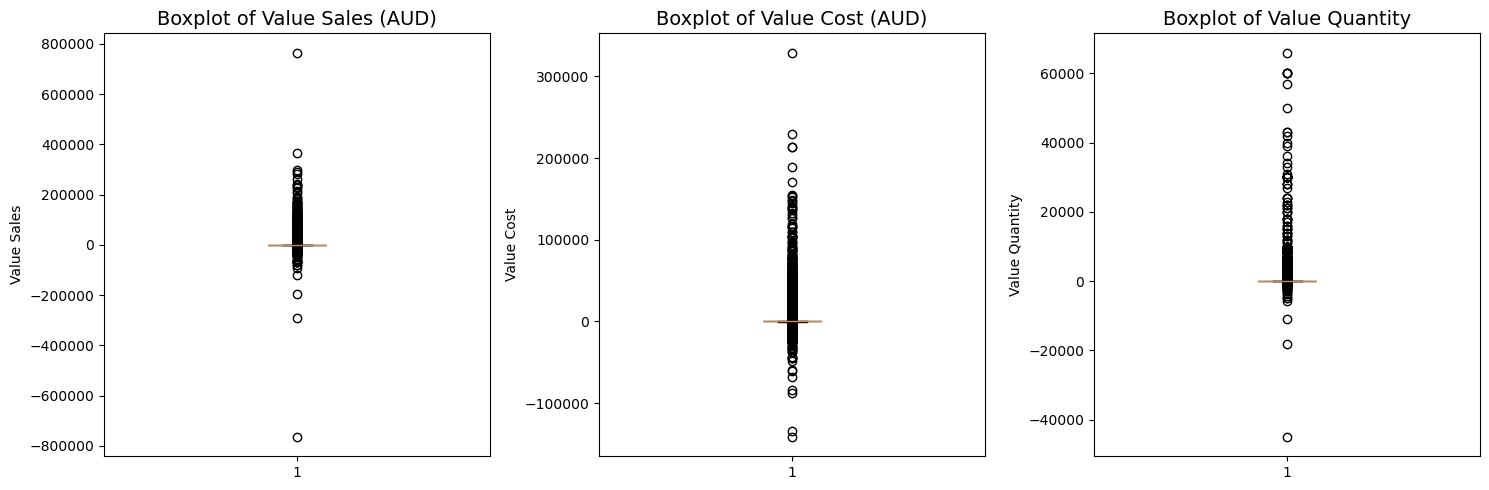

In [22]:
# Selecting only the numeric columns
numeric_columns = df_2012[['value_sales_aud', 'value_cost_aud', 'value_quantity']]

# Create subplots with a better layout
plt.figure(figsize=(15, 5))

# Boxplot for each numeric column
plt.subplot(1, 3, 1)
plt.boxplot(numeric_columns['value_sales_aud'], patch_artist=True, boxprops=dict(facecolor='skyblue'))
plt.title('Boxplot of Value Sales (AUD)', fontsize=14)
plt.ylabel('Value Sales')

plt.subplot(1, 3, 2)
plt.boxplot(numeric_columns['value_cost_aud'], patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title('Boxplot of Value Cost (AUD)', fontsize=14)
plt.ylabel('Value Cost')

plt.subplot(1, 3, 3)
plt.boxplot(numeric_columns['value_quantity'], patch_artist=True, boxprops=dict(facecolor='lightcoral'))
plt.title('Boxplot of Value Quantity', fontsize=14)
plt.ylabel('Value Quantity')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

### 9. Combine two dataframe

In [23]:
# Combine two dataset for further testing purposes
df_combined = pd.concat([df_2012, df_2013], ignore_index=True)

# Print the shape of dataset after combining
#df_combined.shape

## SECTION 2: EXPLORATORY INSIGHTS

### 1. Sales trend overtime (Currency: AUD)

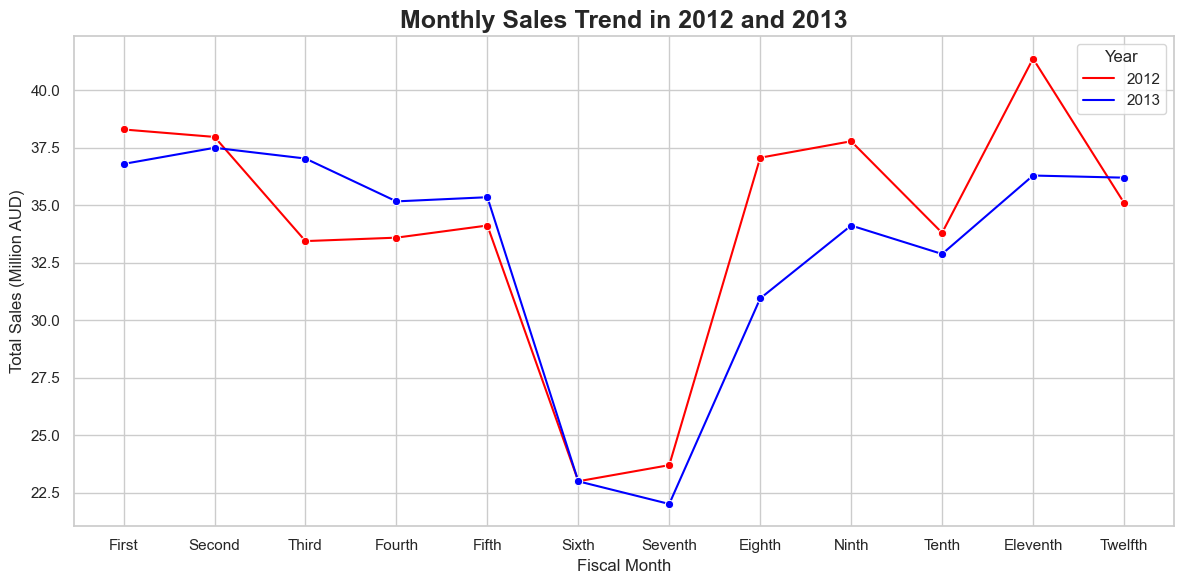

In [24]:
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Set the Seaborn style for aesthetics
sns.set(style="whitegrid")

# Calculate total sales per month for both years and convert to millions
monthly_sales_2012 = df_2012.groupby('fiscal_month')['value_sales_aud'].sum() / 1e6
monthly_sales_2013 = df_2013.groupby('fiscal_month')['value_sales_aud'].sum() / 1e6

# Create a DataFrame to combine both years for easier plotting
df_sales = pd.DataFrame({
    'Fiscal Month': list(monthly_sales_2012.index) * 2,
    'Total Sales (Million AUD)': list(monthly_sales_2012.values) + list(monthly_sales_2013.values),
    'Year': ['2012'] * 12 + ['2013'] * 12
})

# Month labels in the desired format
month_labels = ["First", "Second", "Third", "Fourth", "Fifth", "Sixth", "Seventh", "Eighth", "Ninth", "Tenth", "Eleventh", "Twelfth"]

# Initialize the plot
plt.figure(figsize=(12, 6))

# Plot the sales trends for 2012 and 2013 using Seaborn lineplot
sns.lineplot(data=df_sales, x='Fiscal Month', y='Total Sales (Million AUD)', hue='Year', marker='o', palette=['red', 'blue'])

# Set plot details
plt.title('Monthly Sales Trend in 2012 and 2013', fontsize=18, fontweight='bold')
plt.xlabel('Fiscal Month')
plt.ylabel('Total Sales (Million AUD)')
plt.xticks(ticks=range(1, 13), labels=month_labels)

# Format y-axis to show in millions
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.1f}'))
plt.legend(title='Year')  # Show the legend with a title
plt.tight_layout()  # Adjust layout to prevent clipping

plt.show()

### 2. Profitability by Customer Location

In [25]:
# Define the mapping dictionary for customer_district_code
district_mapping = {
    410: 'Townsville',
    300: 'Melbourne',
    500: 'Adelaide',
    310: 'Tasmania',
    400: 'Brisbane',
    200: 'Sydney',
    210: 'ACT/Riverina',
    720: 'Intercompany Sales',
    710: 'Head Office Sales',
    600: 'Perth',
    510: 'Darwin',
    530: 'South Island - NZ',
    535: 'Central Region - NZ',
    540: 'Northern Region - NZ',
    520: 'Inlite - NZ',
    545: 'Head Office - NZ'
}

# Apply the mapping to the customer_district_code in both dataframes
df_2012['customer_district_name'] = df_2012['customer_district_code'].map(district_mapping)
df_2013['customer_district_name'] = df_2013['customer_district_code'].map(district_mapping)
df_combined['customer_district_name'] = df_combined['customer_district_code'].map(district_mapping)

In [26]:
# Calculate profit for both 2012 and 2013 with updated customer district codes
df_2012['profit'] = df_2012['value_sales_aud'] - df_2012['value_cost_aud']
df_2013['profit'] = df_2013['value_sales_aud'] - df_2013['value_cost_aud']

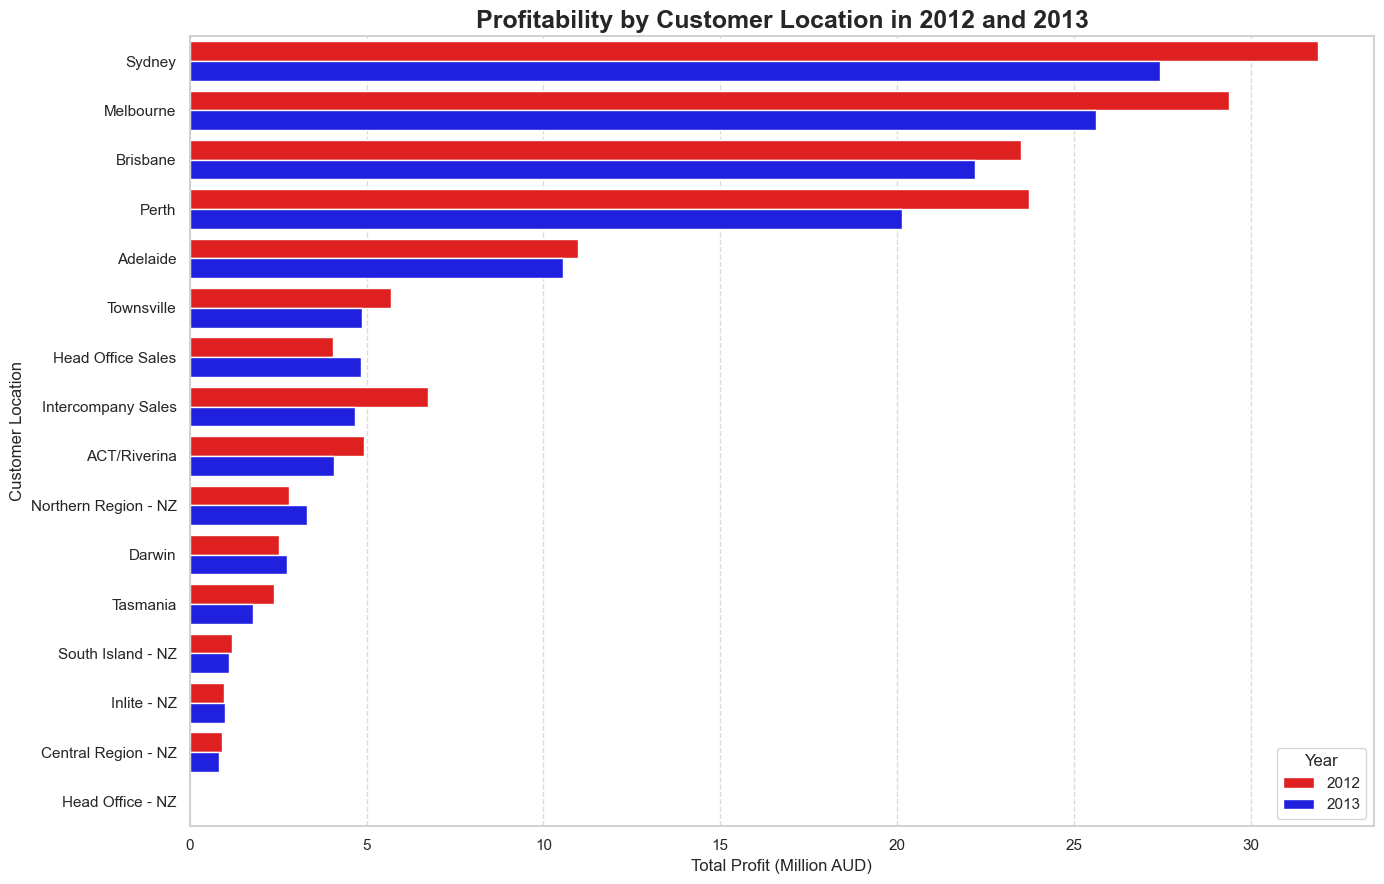

In [27]:
# Convert profits to millions for each year
district_profit_2012 = df_2012.groupby('customer_district_name')['profit'].sum() / 1e6
district_profit_2013 = df_2013.groupby('customer_district_name')['profit'].sum() / 1e6

# Combine results into a single DataFrame for both years and sort by 2012 in descending order
combined_profit = pd.DataFrame({
    '2012': district_profit_2012,
    '2013': district_profit_2013
}).sort_values(by='2013', ascending=False)  # Sort based on 2013 profits in descending order

# Melt the DataFrame for Seaborn compatibility (long format)
combined_profit_melted = combined_profit.reset_index().melt(id_vars='customer_district_name', var_name='Year', value_name='Total Profit (Million AUD)')

# Set up the plot with Seaborn
plt.figure(figsize=(14, 9))  # Adjusted to make it slightly shorter
sns.set(style="whitegrid")

# Plot with Seaborn's barplot, using a horizontal orientation
sns.barplot(
    data=combined_profit_melted,
    x='Total Profit (Million AUD)',
    y='customer_district_name',
    hue='Year',
    palette=['red', 'blue']
)

# Set plot details with larger, bold title
plt.title('Profitability by Customer Location in 2012 and 2013', fontsize=18, fontweight='bold')
plt.xlabel('Total Profit (Million AUD)')
plt.ylabel('Customer Location')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout() 
plt.show()

### 3. Profitability by Business Area

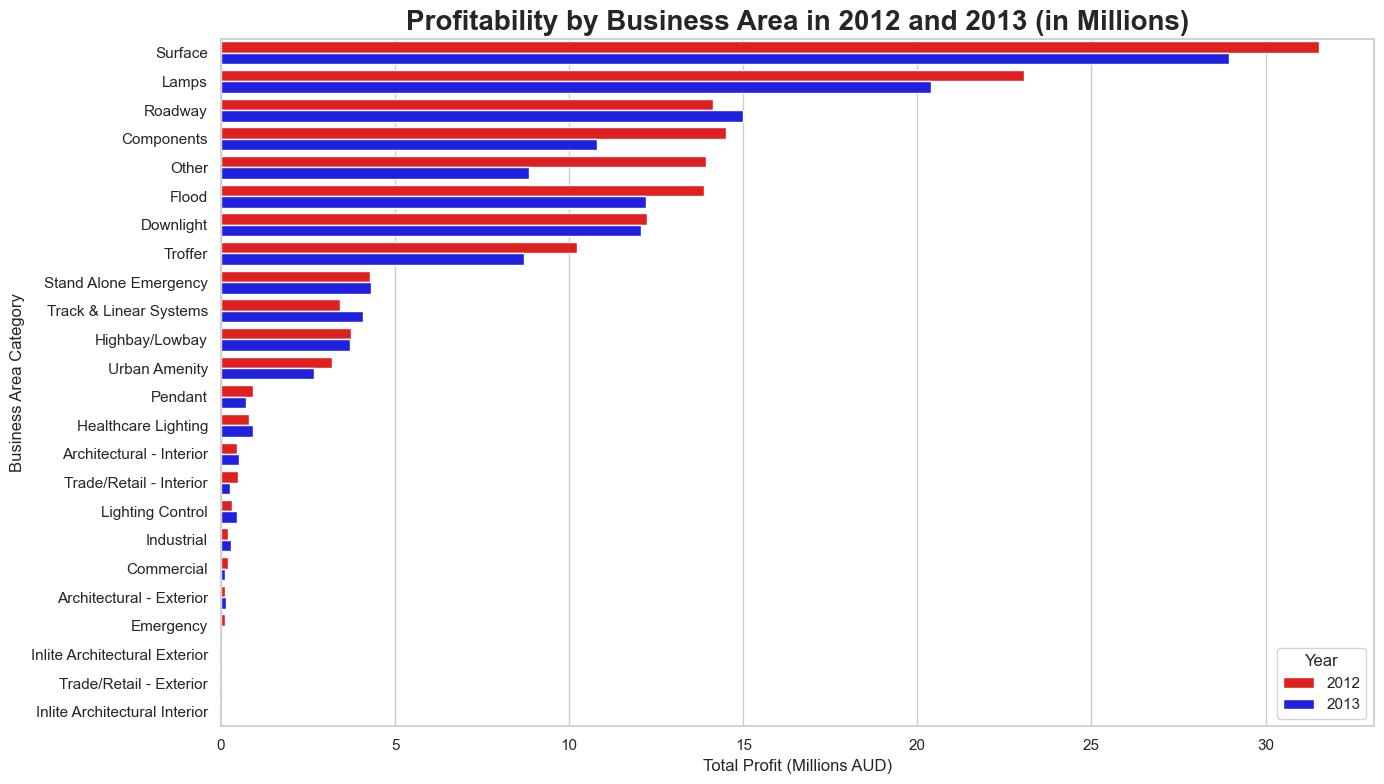

In [28]:
# Group by 'business_area_category' and calculate total sales and total cost for 2012
business_area_profit_2012 = df_2012.groupby('business_area_category').agg(
    total_sales=('value_sales_aud', 'sum'),
    total_cost=('value_cost_aud', 'sum')
).reset_index()

# Calculate total profit for 2012
business_area_profit_2012['total_profit'] = business_area_profit_2012['total_sales'] - business_area_profit_2012['total_cost']

# Group by 'business_area_category' and calculate total sales and total cost for 2013
business_area_profit_2013 = df_2013.groupby('business_area_category').agg(
    total_sales=('value_sales_aud', 'sum'),
    total_cost=('value_cost_aud', 'sum')
).reset_index()

# Calculate total profit for 2013
business_area_profit_2013['total_profit'] = business_area_profit_2013['total_sales'] - business_area_profit_2013['total_cost']

# Merge the two DataFrames on 'business_area_category'
merged_business_area_profit = pd.merge(
    business_area_profit_2012[['business_area_category', 'total_profit']],
    business_area_profit_2013[['business_area_category', 'total_profit']],
    on='business_area_category', suffixes=('_2012', '_2013'), how='outer'
).fillna(0)

# Melt the DataFrame for Seaborn compatibility (long format)
profit_melted = merged_business_area_profit.melt(id_vars='business_area_category', 
                                                 value_vars=['total_profit_2012', 'total_profit_2013'], 
                                                 var_name='Year', 
                                                 value_name='Total Profit (AUD)')

# Map 'total_profit_2012' and 'total_profit_2013' to '2012' and '2013' for readability
profit_melted['Year'] = profit_melted['Year'].replace({'total_profit_2012': '2012', 'total_profit_2013': '2013'})

# Sort the data from highest to lowest based on total profit
profit_melted = profit_melted.sort_values(by='Total Profit (AUD)', ascending=False)

# Convert 'Total Profit (AUD)' to millions (divide by 1,000,000)
profit_melted['Total Profit (AUD)'] = profit_melted['Total Profit (AUD)'] / 1_000_000

# Set up the plot
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")

# Plot with Seaborn (horizontal orientation)
sns.barplot(
    data=profit_melted,
    x='Total Profit (AUD)',  # Total profit on the x-axis for horizontal bars
    y='business_area_category',  # Business area categories on the y-axis
    hue='Year',
    palette=['red', 'blue']
)

# Set plot details
plt.title('Profitability by Business Area in 2012 and 2013 (in Millions)', fontsize=20, fontweight='bold')
plt.xlabel('Total Profit (Millions AUD)')
plt.ylabel('Business Area Category')

# Move the legend to the lower right corner
plt.legend(title='Year', loc='lower right')

plt.tight_layout()  # Adjust layout to prevent clipping
plt.show()

### 4. Profit Margin by Product

In [29]:
# Define the mapping based on the provided data
technology_mapping = {
    'SYLV': 'Sylvania',
    'NA': 'NA',
    'PIER': 'Pierlite',
    '96': '96',
    '219': 'Overseas Other',
    '92': 'Lithonia Lighting (lith01/02/03)',
    '214': 'Lamps Others',
    '380': 'Sealite (seal03)',
    '102': 'Flowin (flow01/02)',
    '123': 'P T Pierlite Indonesia (ptpi01)',
    '110': 'Fosnova (fosn01)',
    '98': 'Diffusers',
    '213': 'High Bright (high02)',
    '580': 'Slow Moving / Obsolete',
    '108': 'Disano (disa02/03)',
    '999': '999',
    '198': '198',
    'SCHR': 'Schreder',
    '82': '82',
    '140': 'Simes (sime01)',
    '540': 'Bodies',
    'AUST': 'Austube (lclm01/02)',
    '480': 'Lampholders',
    '760': 'Screws Studs Inserts',
    '460': 'Terminal Blocks',
    '600': 'Endcaps & Diff Clips Etc',
    '520': 'Wire Guards',
    '998': 'Grommets & Wedges',
    '570': 'Brackets',
    '280': 'Ignitors',
    '330': 'Lamps Fluoro',
    '220': 'Ballasts',
    '415': 'Cartons',
    '340': 'Lamps Mercury',
    '225': 'Electronic Ballasts',
    'CSE': 'Cse Ex',
    '565': 'Covers',
    '410': 'Packing Material',
    '560': 'Reflectors',
    '800': 'Bolts & Nuts',
    '680': 'Aluminium Extrusions & Sheets',
    '320': 'Batteries',
    '550': 'Trims',
    '400': 'Wires & Cables',
    '160': 'Schuch (schu01)',
    '440': 'Starter Switches',
    '420': 'Flex & Plugs',
    '500': 'Control Gear/boxes',
    '555': 'Frames',
    '360': 'Lamps Metal Halide',
    '290': 'Transformers',
    '780': 'Washers & Circlips',
    '545': 'Gear Trays',
    '181': "V'lux (vlux01)",
    '240': 'Capacitors',
    '640': 'Bollards',
    '820': 'Rivets',
    '595': 'Louvres',
    '300': 'Inverters',
    '830': 'Clips/springs/hinges',
    '70': '70',
    '850': 'Finish Good Components',
    '86': '86',
    '720': 'Sleeves Seals Gaskets Etc',
    '740': 'Labels & Stickers',
    '310': 'Drivers',
    'FGDFT': 'Finished Goods',
    '350': 'Lamps High Pressure Sodium',
    '206': 'Nimbus Lighting (nimb01)',
    '64': 'PNZ - Glg Nz',
    'PNZ': 'Crompton',
    '63': '63',
    'CROM': 'CROM',
    '100': 'Eclatec (ecla01/02)',
    '78': '78',
    '207': 'Troll Lighting (trol01)',
    '208': 'Planet Lighting (plan01)',
    '76': '76',
    '211': 'Side Lighting (side01/02)',
    '205': 'Atomis Lighting (atom01)',
    '85': '85',
    '90': '90',
    '68': '68',
    '130': 'Yaohua Lux (yaoh01)',
    'GLG': 'Glg',
    'INLIT': 'Inlite Au',
    '72': '72',
    '61': '61',
    '880': 'Local Purch - Fg',
    '217': 'Siteco (site01/03)',
    '215': 'Havells Europe', # have02, Have04 & Have05
    '80': '80',
    '210': 'Traxon Technologies (trax01/02)',
    'INZ': 'Inlite Nz',
    '250': 'Blocking Inductors',
    '118': 'Relight Technology (reli02)',
    '66': '66'
}

# Map to Dataframe
df_2012['technology_group_name'] = df_2012['technology_group_code'].map(technology_mapping)
df_2013['technology_group_name'] = df_2013['technology_group_code'].map(technology_mapping)
df_combined['technology_group_name'] = df_combined['technology_group_code'].map(technology_mapping)

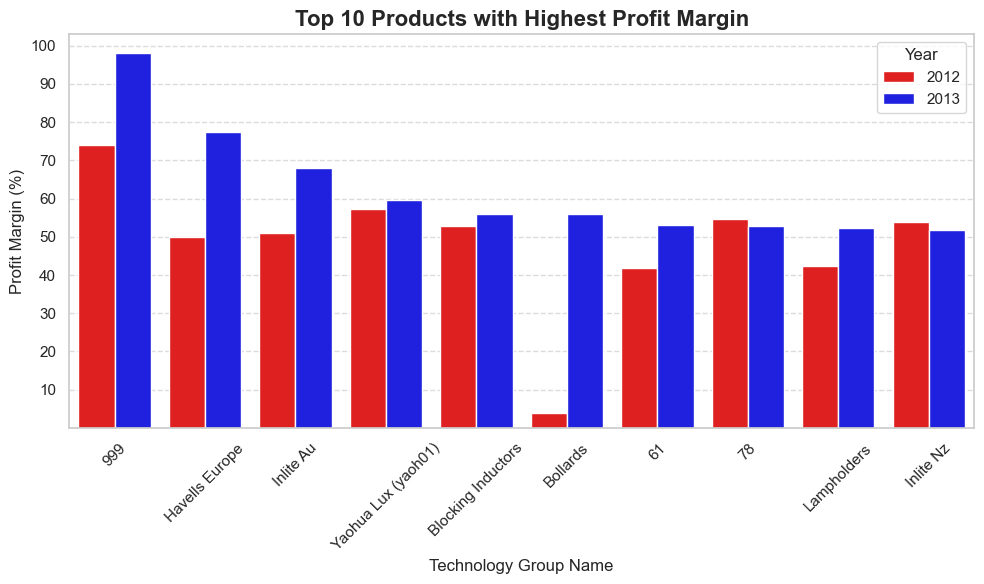

In [30]:
from matplotlib.ticker import MaxNLocator

# Group by technology group name and calculate total profit and total sales for each year
technology_group_profit_2012 = df_2012.groupby('technology_group_name')['profit'].sum()
technology_group_profit_2013 = df_2013.groupby('technology_group_name')['profit'].sum()

technology_group_sales_2012 = df_2012.groupby('technology_group_name')['value_sales_aud'].sum()
technology_group_sales_2013 = df_2013.groupby('technology_group_name')['value_sales_aud'].sum()

# Combine results into a single DataFrame for both years
combined_profit = pd.DataFrame({
    '2012 Profit': technology_group_profit_2012,
    '2013 Profit': technology_group_profit_2013,
    '2012 Sales': technology_group_sales_2012,
    '2013 Sales': technology_group_sales_2013
})

# Calculate profit margin (profit/sales) for each year and convert to percentage
combined_profit['2012 Profit Margin'] = (combined_profit['2012 Profit'] / combined_profit['2012 Sales']) * 100
combined_profit['2013 Profit Margin'] = (combined_profit['2013 Profit'] / combined_profit['2013 Sales']) * 100

# Sort the combined profit based on 2013 Profit Margin in descending order to find the top
combined_profit_sorted = combined_profit.sort_values(by='2013 Profit Margin', ascending=False)

# Select the top 10 technology groups based on the 2013 Profit Margin
top_10_profit_margin = combined_profit_sorted.head(10)

# Melt the DataFrame for Seaborn compatibility (long format)
top_10_profit_margin_melted = top_10_profit_margin.reset_index().melt(
    id_vars='technology_group_name',
    value_vars=['2012 Profit Margin', '2013 Profit Margin'],
    var_name='Year',
    value_name='Profit Margin (%)'
)

# Map the 'Year' values for readability
top_10_profit_margin_melted['Year'] = top_10_profit_margin_melted['Year'].replace({
    '2012 Profit Margin': '2012',
    '2013 Profit Margin': '2013'
})

# Set up the plot with Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create the bar plot
sns.barplot(
    data=top_10_profit_margin_melted,
    x='technology_group_name',
    y='Profit Margin (%)',
    hue='Year',
    palette=['red', 'blue']
)

# Set plot details
plt.title('Top 10 Products with Highest Profit Margin', fontsize=16, fontweight='bold')
plt.ylabel('Profit Margin (%)')
plt.xlabel('Technology Group Name')
plt.xticks(rotation=45)

# Set y-axis ticks to a scale of 10
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=True, prune='both', nbins=11))  # Change number of bins as necessary

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()

# Show the plot
plt.show()

### 5. Cost of Sales by Product

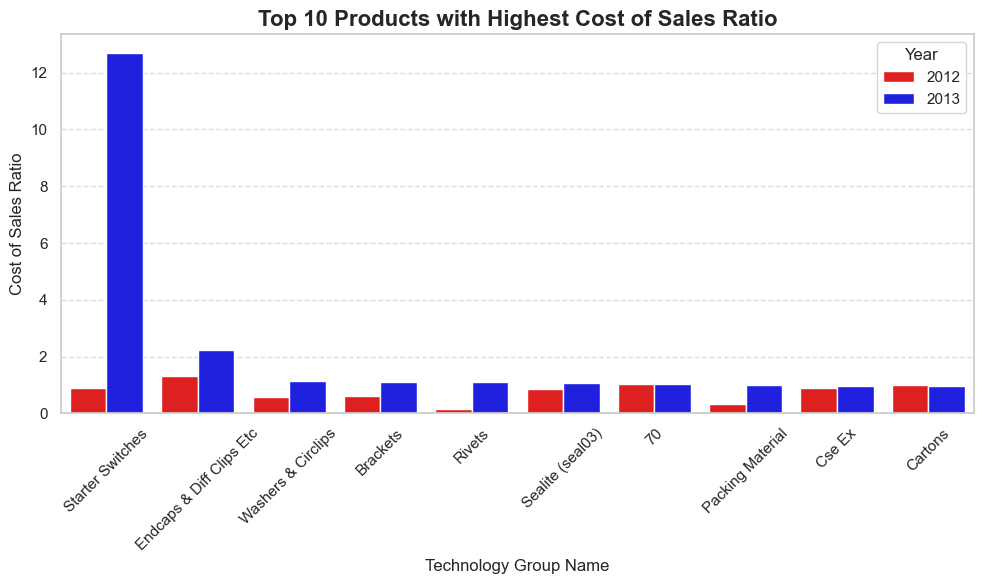

In [31]:
# Group by technology group name and calculate total cost and total sales for each year
technology_group_cost_2012 = df_2012.groupby('technology_group_name')['value_cost_aud'].sum()
technology_group_cost_2013 = df_2013.groupby('technology_group_name')['value_cost_aud'].sum()
technology_group_sales_2012 = df_2012.groupby('technology_group_name')['value_sales_aud'].sum()
technology_group_sales_2013 = df_2013.groupby('technology_group_name')['value_sales_aud'].sum()

# Combine results into a single DataFrame for both years
combined_cost_sales = pd.DataFrame({
    '2012 Cost': technology_group_cost_2012,
    '2013 Cost': technology_group_cost_2013,
    '2012 Sales': technology_group_sales_2012,
    '2013 Sales': technology_group_sales_2013
})

# Calculate cost-to-sales ratio for each year
combined_cost_sales['2012 Cost of Sales Ratio'] = combined_cost_sales['2012 Cost'] / combined_cost_sales['2012 Sales']
combined_cost_sales['2013 Cost of Sales Ratio'] = combined_cost_sales['2013 Cost'] / combined_cost_sales['2013 Sales']

# Sort the combined data based on 2013 Cost to Sales Ratio in descending order
combined_cost_sales_sorted = combined_cost_sales.sort_values(by='2013 Cost of Sales Ratio', ascending=False)

# Select the top 10 technology groups based on the 2013 Cost to Sales Ratio
top_10_cost_sales_ratio = combined_cost_sales_sorted.head(10)

# Melt the DataFrame for Seaborn compatibility (long format)
top_10_cost_sales_ratio_melted = top_10_cost_sales_ratio.reset_index().melt(
    id_vars='technology_group_name',
    value_vars=['2012 Cost of Sales Ratio', '2013 Cost of Sales Ratio'],
    var_name='Year',
    value_name='Cost of Sales'
)

# Map the 'Year' values for readability
top_10_cost_sales_ratio_melted['Year'] = top_10_cost_sales_ratio_melted['Year'].replace({
    '2012 Cost of Sales Ratio': '2012',
    '2013 Cost of Sales Ratio': '2013'
})

# Set up the plot with Seaborn
plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

# Create the bar plot
sns.barplot(
    data=top_10_cost_sales_ratio_melted,
    x='technology_group_name',
    y='Cost of Sales',  # Displaying the cost of sales ratio
    hue='Year',
    palette=['red', 'blue']
)

# Set plot details
plt.title('Top 10 Products with Highest Cost of Sales Ratio', fontsize=16, fontweight='bold')
plt.ylabel('Cost of Sales Ratio')
plt.xlabel('Technology Group Name')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Year')
plt.tight_layout()

# Show the plot
plt.show()

## SECTION 3: TEST SUB SAMEPLE DIFFERENCES

In [32]:
# Import necessary libraries
from scipy.stats import ttest_ind

In [33]:
# Add columns 'value_profit'
df_combined['value_profit'] = df_combined['value_sales_aud'] - df_combined['value_cost_aud']

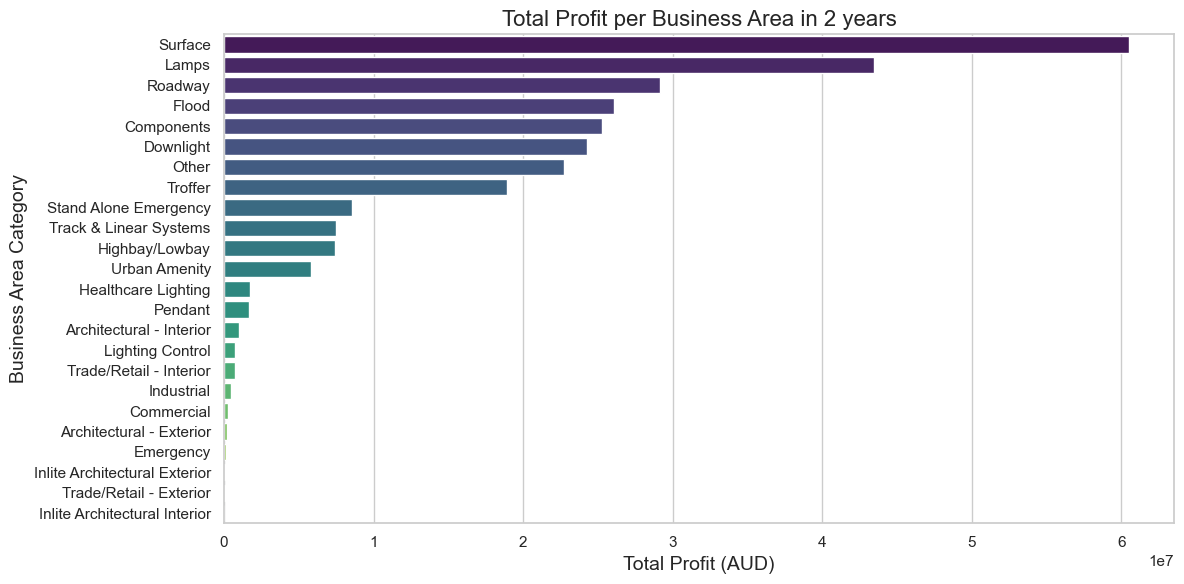

In [34]:
# Calculate the total profit for each business area category
df_sum_profit = df_combined.groupby('business_area_category')['value_profit'].sum().reset_index()

# Sort by profit for clearer visualization
df_sum_profit = df_sum_profit.sort_values(by='value_profit', ascending=False)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Create a barplot for the average profit per business area category
sns.barplot(data=df_sum_profit, x='value_profit', y='business_area_category', palette='viridis')

# Customize the plot
plt.title("Total Profit per Business Area in 2 years", fontsize=16)
plt.xlabel("Total Profit (AUD)", fontsize=14)
plt.ylabel("Business Area Category", fontsize=14)

# Show the plot
plt.tight_layout()
plt.show()

### Question 1: 
Null Hypothesis (H0): There is no difference in the average order value between the Lamps and Surface.\
Alternative Hypothesis (H1): There is a difference in the average order value between the Lamps and Surface.

In [35]:
# Filter the dataset for each industry
sample_a = df_combined[df_combined['business_area_category'] == 'Lamps']['value_profit']
sample_b = df_combined[df_combined['business_area_category'] == 'Surface']['value_profit']

# Perform a two-sample t-test
t_stat, p_value = ttest_ind(sample_a, sample_b, equal_var=False)  # Use equal_var=False as we assume that variances are not equal

# Output the results
print("Two-Sample T-Test Results:")
print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis. There is a statistically significant difference in the average order value between 'Lamps' and 'Surface' industries.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that there is a significant difference in the average order value between 'Lamps' and 'Surface' industries.")

Two-Sample T-Test Results:
T-Statistic: -68.59290984522995
P-Value: 0.0
Reject the null hypothesis. There is a statistically significant difference in the average order value between 'Lamps' and 'Surface' industries.


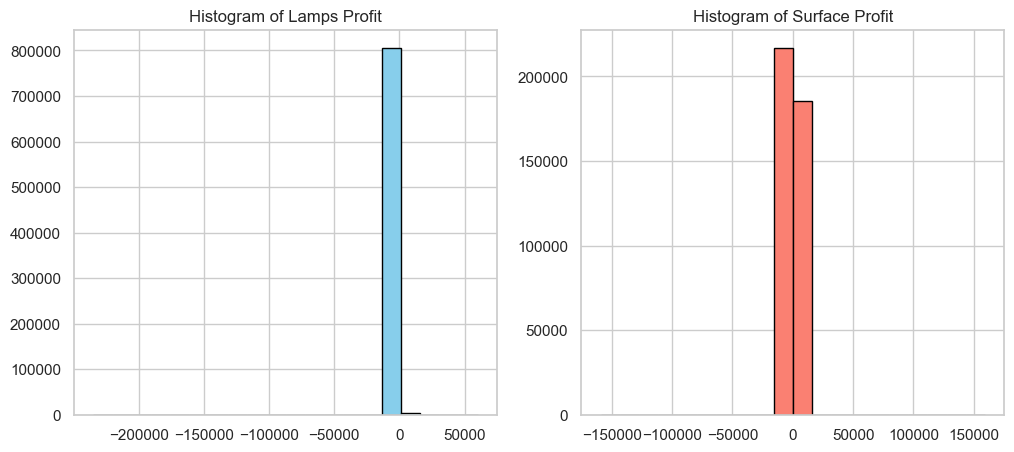

In [36]:
# Normality
plt.figure(figsize=(12, 5))

# Histogram for Roadway orders
plt.subplot(1, 2, 1)
plt.hist(sample_a, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Lamps Profit')

# Histogram for Architectural - Exterior orders
plt.subplot(1, 2, 2)
plt.hist(sample_b, bins=20, color='salmon', edgecolor='black')
plt.title('Histogram of Surface Profit')
plt.show()

**Assumption**\
The three assumptions of Independence of Observations, Continuous Data, Random Sampling are met by the nature of the dataset and the question itself. Different from standard two sample t-test, we use Welch’s t-test which does not assume equal variances between the groups. Last but not least, when checking the normality of two sub sample sets, the histograms indicated significant skewness, with extreme outliers, which violates the normality assumption for our t-test. 

Hence, we performed data transformation log(x+1) to reduce the skewness and re-run the t-test again. The result after data transformation is T-Statistic: -113.2077 and P-Value: 0.0. Since the p-value of 0.0 is still smaller than alpha, we are confident to reject the null hypothesis, meeting all the assumptions.

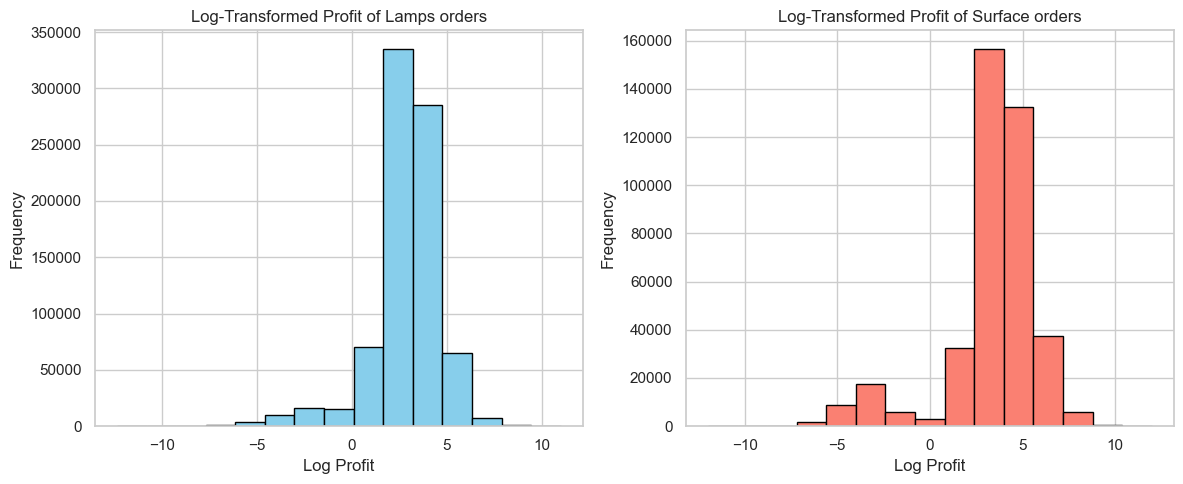

In [37]:
# Apply log1p transformation to handle zero values (log(x+1))
df_combined['log_value_profit'] = df_combined['value_profit'].apply(lambda x: np.sign(x) * np.log1p(abs(x)))

# Separate data into two groups with the transformed log sales values
log_sample_a = df_combined[df_combined['business_area_category'] == 'Lamps']['log_value_profit']
log_sample_b = df_combined[df_combined['business_area_category'] == 'Surface']['log_value_profit']

# Plot histograms for log-transformed data
plt.figure(figsize=(12, 5))

# # Histogram for log profit of Lamps
plt.subplot(1, 2, 1)
plt.hist(log_sample_a, bins=15, color='skyblue', edgecolor='black')
plt.title("Log-Transformed Profit of Lamps orders")
plt.xlabel("Log Profit")
plt.ylabel("Frequency")

# Histogram for log profit of Surface 
plt.subplot(1, 2, 2)
plt.hist(log_sample_b, bins=15, color='salmon', edgecolor='black')
plt.title("Log-Transformed Profit of Surface orders")
plt.xlabel("Log Profit")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [38]:
# Run the independent two-sample t-test
t_stat_log, p_value_log = ttest_ind(log_sample_a, log_sample_b, equal_var=False)

# Output results
print("T-Statistic:", t_stat_log)
print("P-Value:", p_value_log)

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a statistically significant difference in the average order value between 'Lamps' and 'Surface' industries.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that there is a significant difference in the average order value between 'Lamps' and 'Surface' industries.")

T-Statistic: -113.20769575307541
P-Value: 0.0
Reject the null hypothesis. There is a statistically significant difference in the average order value between 'Lamps' and 'Surface' industries.


### Question 2:

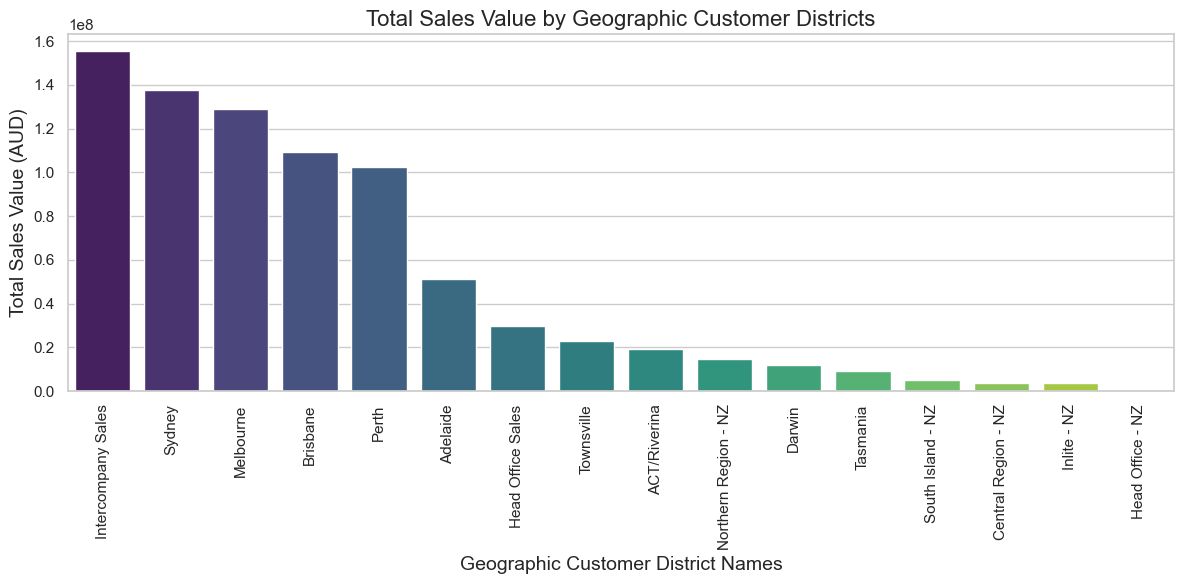

In [39]:
# Calculate the mean sales value for each customer districts
sum_sales_geo = df_combined.groupby('customer_district_name')['value_sales_aud'].sum().reset_index()

# Sort by sales value for clearer visualization
sum_sales_geo = sum_sales_geo.sort_values(by='value_sales_aud', ascending=False)

# Set up the figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Create a barplot for the average sales value per customer districts
sns.barplot(data=sum_sales_geo, x='customer_district_name', y='value_sales_aud', palette='viridis')

# Customize the plot
plt.title("Total Sales Value by Geographic Customer Districts", fontsize=16)
plt.xlabel("Geographic Customer District Names", fontsize=14)
plt.ylabel("Total Sales Value (AUD)", fontsize=14)

# Rotate x-axis labels to avoid overlap
plt.xticks(rotation=90)

# Show the plot
plt.tight_layout()
plt.show()

**Hypothesis**\
Null Hypothesis (H0): There is no difference in the average sales revenue per order between Sydney and Melbourne.\
Alternative Hypothesis (H1): There is a difference in the average sales revenue per order between Sydney and Melbourne.

In [40]:
# Filter the dataset for each industry
sample_e = df_combined[df_combined['customer_district_code'] == 200]['value_sales_aud']
sample_f = df_combined[df_combined['customer_district_code'] == 300]['value_sales_aud']

# Perform a two-sample t-test
t_stat, p_value = ttest_ind(sample_e, sample_f, equal_var=False)  # Use equal_var=False as we assume that variances are not equal

# Output the results
print("Two-Sample T-Test Results:")
print(f"T-Statistic: {t_stat}")
print(f"P-Value: {p_value}")

# Interpretation
alpha = 0.05  # Significance level
if p_value < alpha:
    print("Reject the null hypothesis. There is a statistically significant difference in the average sales revenue per order between Sydney and Melbourne.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence to conclude a significant difference in the average sales revenue per order between Sydney and Melbourne.")

Two-Sample T-Test Results:
T-Statistic: 5.407708419703647
P-Value: 6.385366609116579e-08
Reject the null hypothesis. There is a statistically significant difference in the average sales revenue per order between Sydney and Melbourne.


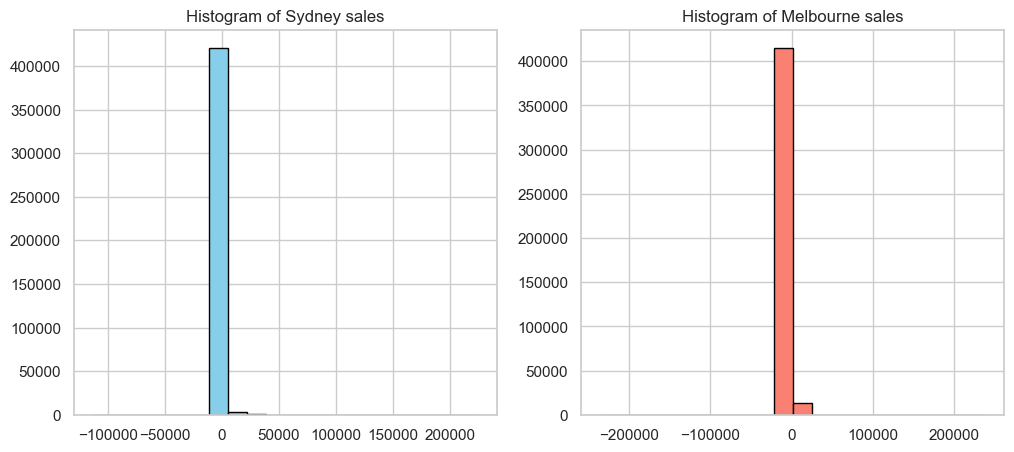

In [41]:
# Check normality
plt.figure(figsize=(12, 5))

# Histogram for Sydney sales
plt.subplot(1, 2, 1)
plt.hist(sample_e, bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Sydney sales')

# Histogram for Melbourne sales
plt.subplot(1, 2, 2)
plt.hist(sample_f, bins=20, color='salmon', edgecolor='black')
plt.title('Histogram of Melbourne sales')
plt.show()

**Assumptions**\
The three assumptions of Independence of Observations, Continuous Data, Random Sampling are met by the nature of the dataset and the question itself. Different from standard two sample t-test, we use Welch’s t-test which does not assume equal variances between the groups. Last but not least, when checking the normality of two sub sample sets, the histograms indicated significant skewness, with extreme outliers, which violates the normality assumption for our t-test. 

Hence, we performed data transformation log(x+1) to reduce the skewness and re-run the t-test again.
The result after data transformation is T-Statistic: -27.4286 and P-Value: 1.4759174265232833e-165. Since the p-value is still smaller than alpha, we are confident to reject the null hypothesis, meeting all of the assumptions.

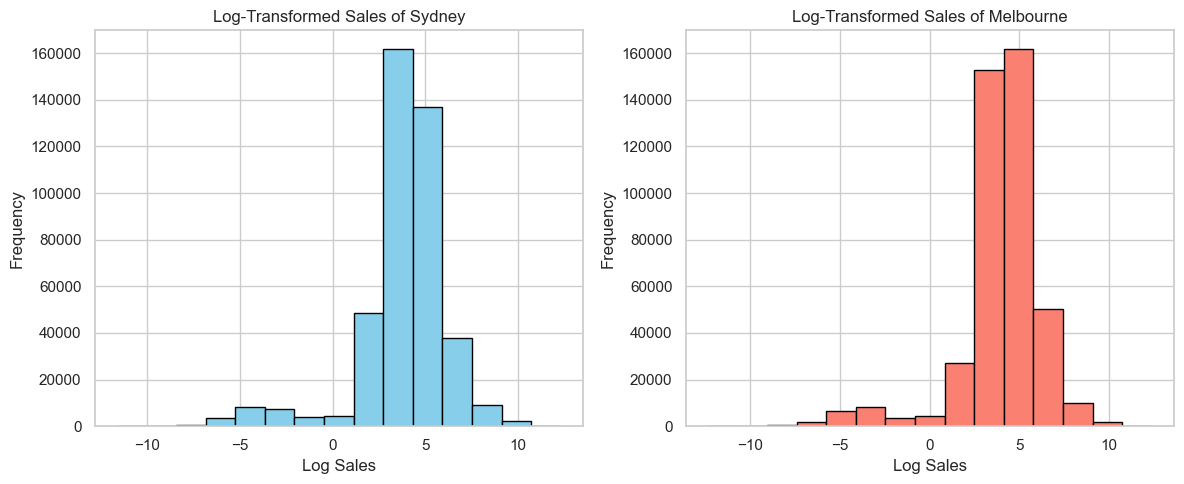

In [42]:
# Since the data distribution is not really normally distributed
# Apply log1p transformation to handle zero values (log(x+1))
df_combined['log_value_sales'] = df_combined['value_sales_aud'].apply(lambda x: np.sign(x) * np.log1p(abs(x)))

# Separate data into two groups with the transformed log sales values
log_sample_e = df_combined[df_combined['customer_district_code'] == 200]['log_value_sales']
log_sample_f = df_combined[df_combined['customer_district_code'] == 300]['log_value_sales']

# Plot histograms for log-transformed data
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(log_sample_e, bins=15, color='skyblue', edgecolor='black')
plt.title("Log-Transformed Sales of Sydney")
plt.xlabel("Log Sales")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(log_sample_f, bins=15, color='salmon', edgecolor='black')
plt.title("Log-Transformed Sales of Melbourne")
plt.xlabel("Log Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [43]:
# Run the independent two-sample t-test again
t_stat_log, p_value_log = ttest_ind(log_sample_e, log_sample_f, equal_var=False)

# Output results
print("T-Statistic:", t_stat_log)
print("P-Value:", p_value_log)

# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis. There is a statistically significant difference in the average order value between Sydney and Melbourne.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that there is a significant difference in the average order value between Sydney and Melbourne.")

T-Statistic: -27.428635787105407
P-Value: 1.4759174265232833e-165
Reject the null hypothesis. There is a statistically significant difference in the average order value between Sydney and Melbourne.


## SECTION 4: INFERENCE

### Question 1: What is the impact of value quantity, value cost, and order type category on value_sales in 2012?

#### Create a sub Dataframe from df_2012

In [44]:
# Select the specific columns from df_2012
df_2012_processed = df_2012[['value_sales_aud', 'value_quantity', 'value_cost_aud', 'order_type_code']]

# # Display the new dataframe
# print(df_2012_processed.head())

#### Prepare df_2012_processed dataframe

In [45]:
# One-Hot Encoding for Customer District Code and Business Area Code
df_2012_processed = pd.get_dummies(df_2012_processed, columns=['order_type_code'], dtype=int, drop_first=True)

In [46]:
#Drop null values 
df_2012_processed.dropna(inplace=True)

In [47]:
# Convert all columns to numeric, forcing errors to NaN
df_2012_processed = df_2012_processed.apply(pd.to_numeric, errors='coerce')

In [48]:
# Drop rows with NaN values after conversion
df_2012_processed = df_2012_processed.dropna()

# Define variables for regression
X = df_2012_processed.drop(columns=['value_sales_aud'])
y = df_2012_processed['value_sales_aud']  # Dependent variable

#### Multiple regression analysis

In [49]:
import statsmodels.api as sm

# Add a constant term to the independent variables (intercept)
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        value_sales_aud   R-squared:                       0.788
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                 1.034e+05
Date:                Wed, 06 Nov 2024   Prob (F-statistic):               0.00
Time:                        23:44:03   Log-Likelihood:            -8.8270e+06
No. Observations:             1032119   AIC:                         1.765e+07
Df Residuals:                 1032081   BIC:                         1.765e+07
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3647.1942    

In [50]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns

#Contain two columns, the first is the name of the feature, second is VIF

#X.shape[1] tells us how many features (or columns) we have in our dataset X. If we have, say, 5 features, X.shape[1] would be 5.
#range(X.shape[1]): This creates a sequence of numbers from 0 to the number of features minus one (so in our example, from 0 to 4). Each number corresponds to a different feature.
#variance_inflation_factor(X.values, i): For each feature (represented by i), this function calculates the VIF. 
#The function takes in all the data from X (as a NumPy array using X.values) and the specific feature index i to calculate the VIF.
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

                Feature          VIF
0                 const  2224.429385
1        value_quantity     1.065532
2        value_cost_aud     1.085402
3   order_type_code_AES    11.358308
4   order_type_code_CDG    10.779922
5   order_type_code_COA     1.079929
6   order_type_code_COP     2.128247
7   order_type_code_CPR     1.545042
8   order_type_code_CRD    53.081516
9   order_type_code_CRP     1.342471
10  order_type_code_CRR    52.085043
11  order_type_code_CSH     2.549955
12  order_type_code_CSO     1.002154
13  order_type_code_EDI   127.328072
14  order_type_code_EDS     1.654686
15  order_type_code_EXP     7.669172
16  order_type_code_MIN     2.137056
17  order_type_code_NOH    19.317613
18  order_type_code_NOR   334.867224
19  order_type_code_NOS     3.324180
20  order_type_code_OBS     1.079706
21  order_type_code_PGS     1.029615
22  order_type_code_PM0     1.008622
23  order_type_code_PMO    14.150433
24  order_type_code_PPD     1.103399
25  order_type_code_PPO    14.669560
2

The VIF analysis aids in ensuring that predictors are not overly correlated, which makes the model’s results more reliable and interpretable. According to the table below, all the independent variables that have VIF > 5 belongs to categorical variables which has been encoded through One-Hot-Encoding, which make the multicollinearity understandable.

### Question 2: How do value sales, value cost, bonus group category influence the overall sales price of the company in 2013?

#### Create a sub DataFrame from df_2013

In [51]:
# Create a copy of df_2013
df_2013_copy = df_2013.copy()

# Calculate sales_price, handling division by zero
df_2013_copy['sales_price'] = df_2013_copy['value_sales_aud'] / df_2013_copy['value_quantity'].replace(0, np.nan)

# Prepare df_2013_prepared by selecting the required columns
df_2013_prepared = df_2013_copy[['value_sales_aud', 'value_cost_aud', 'sales_price', 'bonus_group_code']]

# # Display the new dataframe to verify the columns
# print(df_2013_prepared.head())

#### Prepare df_2013_prepared dataframe

In [52]:
# One-Hot Encoding for Bonus group code and Currency
# df_2013_prepared = pd.get_dummies(df_2013_prepared, columns=['bonus_group_code'], dtype=int)
df_2013_prepared = pd.get_dummies(df_2013_prepared, columns=['bonus_group_code'], drop_first=True, dtype=int)

In [53]:
#Drop null values 
df_2013_prepared.dropna(inplace=True)

In [54]:
# Define dependent and independent variables
y  = df_2013_prepared['sales_price']
X = df_2013_prepared.drop(columns=['sales_price'])

#### Multiple regression analysis

In [55]:
# Add a constant to the independent variables for the intercept
X = sm.add_constant(X)

# Fit the regression model
model = sm.OLS(y, X).fit()

# Get the summary of the regression model
summary = model.summary()

print(summary)

                            OLS Regression Results                            
Dep. Variable:            sales_price   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.103
Method:                 Least Squares   F-statistic:                 3.564e+04
Date:                Wed, 06 Nov 2024   Prob (F-statistic):               0.00
Time:                        23:45:13   Log-Likelihood:            -6.8894e+06
No. Observations:              926951   AIC:                         1.378e+07
Df Residuals:                  926947   BIC:                         1.378e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     87

In [56]:
# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns


vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Display the VIF data
print(vif_data)

                  Feature        VIF
0                   const   6.069127
1         value_sales_aud  14.638478
2          value_cost_aud  14.534333
3  bonus_group_code_Trade   1.029482


To ensure that the predictors do not suffer from multicollinearity, we calculated the Variance Inflation Factor (VIF). The VIF values for value_sales_aud and value_cost_aud are relatively high (14.64 and 14.53, respectively), suggesting some multicollinearity between these variables. However, the VIF for bonus_group_code_Trade is 1.03, indicating no concerns with multicollinearity for this variable. These results suggest that while value_sales_aud and value_cost_aud are related, they still provide valuable insights individually.

## SECTION 5: PREDICTION MODEL

### Prepare dataframe for building model

In [57]:
# Calculate the 'sales_price' column for combined dataframe by dividing 'value_sales_aud' by 'value_quantity',
# and replace any zero values in 'value_quantity' with NaN to avoid division by zero errors
df_combined['sales_price'] = df_combined['value_sales_aud'] / df_combined['value_quantity'].replace(0, np.nan)

# Check for any rows where 'sales_price' is NaN and drop them
df_combined.dropna(subset=['sales_price'], inplace=True)

# # Check the first few rows of the DataFrame to ensure the correctness
# print(df_combined.head())

In [58]:
# Filter for business area code 'Surface'
sur_data = df_combined[df_combined['business_area_category'] == 'Surface']

# # Print sur_data to check 
# sur_data

In [59]:
# Check data types of date columns
# Print the data types
print(sur_data[['calendar_year', 'calendar_month', 'calendar_day']].dtypes)

# Print the null values count as integers
print(sur_data[['calendar_year', 'calendar_month', 'calendar_day']].isnull().sum().astype(int))

calendar_year     int64
calendar_month    int64
calendar_day      int64
dtype: object
calendar_year     0
calendar_month    0
calendar_day      0
dtype: int64


In [60]:
# Group sales_price by week
# Create a 'date' column 
sur_data['date'] = pd.to_datetime(
    sur_data['calendar_year'].astype(str) + '-' +
    sur_data['calendar_month'].astype(str) + '-' +
    sur_data['calendar_day'].astype(str)
)

# Set the date column as the index
sur_data.set_index('date', inplace=True)

# Group by month and calculate the mean sales price
weekly_data = sur_data.resample('W')['sales_price'].mean()

# Convert the Series to a DataFrame 
weekly_data = weekly_data.to_frame(name='sales_price')

# Check the structure
weekly_data['sales_price']

date
2012-01-08    30.301113
2012-01-15    36.268735
2012-01-22    42.505160
2012-01-29    42.170271
2012-02-05    48.514489
                ...    
2013-12-08    58.977677
2013-12-15    53.558996
2013-12-22    58.618535
2013-12-29    23.534718
2014-01-05    17.920939
Freq: W-SUN, Name: sales_price, Length: 105, dtype: float64

In [61]:
# Check the range of sales_price
min_price = weekly_data['sales_price'].min()
max_price = weekly_data['sales_price'].max()

print(f"Sales Price Range: {min_price} to {max_price}")

Sales Price Range: 17.92093915337423 to 103.40803137213372


### Check stationary

In [62]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
result = adfuller(weekly_data['sales_price'].dropna())  # Drop missing values if any
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

# Interpretation of the ADF test result
if result[1] < 0.05:
    print("The series is stationary (reject the null hypothesis).")
else:
    print("The series is non-stationary (fail to reject the null hypothesis).")

ADF Statistic: -5.1368650173542525
p-value: 1.1813474552642552e-05
The series is stationary (reject the null hypothesis).


### Run the model and predict sales price in 2014

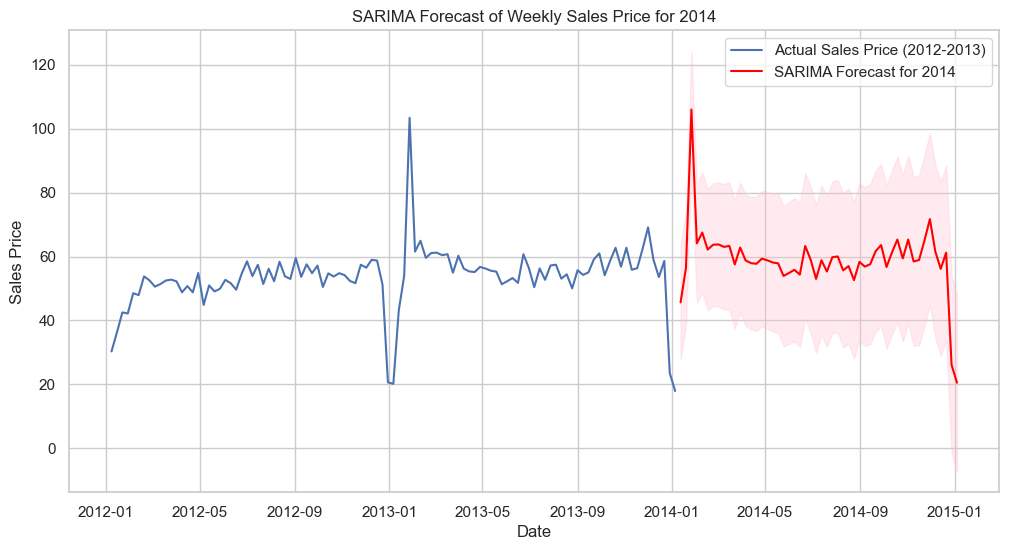

In [63]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Ensure 'sales_price' is in the dataset and indexed by 'date' (already set up)
weekly_data = weekly_data[['sales_price']]

# Train SARIMA model on all data (2012-2013)
p, d, q = 0, 1, 1  # Non-seasonal order
P, D, Q, s = 0, 1, 0, 52  # Seasonal order with seasonality of 52 weeks for yearly pattern

# Fit the SARIMA model
sarima_model = SARIMAX(weekly_data, 
                       order=(p, d, q), 
                       seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Forecast 52 weeks into the future (for 2014)
forecast_steps = 52
forecast = sarima_result.get_forecast(steps=forecast_steps)
forecast_index = pd.date_range(start=weekly_data.index[-1] + pd.Timedelta(weeks=1), 
                               periods=forecast_steps, 
                               freq='W')
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(weekly_data.index, weekly_data['sales_price'], label='Actual Sales Price (2012-2013)')
plt.plot(forecast_index, forecast_values, label='SARIMA Forecast for 2014', color='red')
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMA Forecast of Weekly Sales Price for 2014')
plt.xlabel('Date')
plt.ylabel('Sales Price')
plt.legend()
plt.show()

### Evaluate model performance

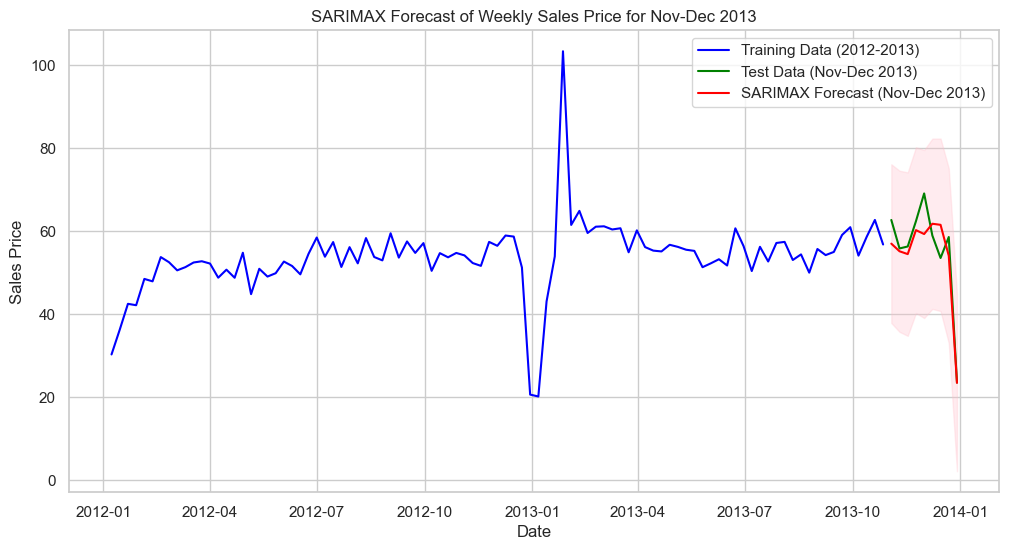

Mean Squared Error (MSE): 25.482200105564853
Root Mean Squared Error (RMSE): 5.047989709336267


In [64]:
from sklearn.metrics import mean_squared_error

# Define the train and test periods
train_data = weekly_data[:'2013-10-31']  # Training data (up to the end of October 2013)
test_data = weekly_data['2013-11-01':'2013-12-29']  # Test data (8 weeks from November 2013 to December 2013)

# Set the SARIMAX parameters
p, d, q = 0, 1, 1  # Non-seasonal order
P, D, Q, s = 0, 1, 0, 52  # Seasonal order with seasonality of 52 weeks for yearly pattern

# Fit the SARIMAX model on the training data
sarimax_model = SARIMAX(train_data, 
                       order=(p, d, q), 
                       seasonal_order=(P, D, Q, s),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarimax_result = sarimax_model.fit(disp=False)

# Forecast the length of the test data (8 weeks)
forecast_steps = len(test_data)  # Forecasting the length of the test data
forecast = sarimax_result.get_forecast(steps=forecast_steps)
forecast_index = test_data.index
forecast_values = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train_data.index, train_data['sales_price'], label='Training Data (2012-2013)', color='blue')
plt.plot(test_data.index, test_data['sales_price'], label='Test Data (Nov-Dec 2013)', color='green')
plt.plot(forecast_index, forecast_values, label='SARIMAX Forecast (Nov-Dec 2013)', color='red')
plt.fill_between(forecast_index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.title('SARIMAX Forecast of Weekly Sales Price for Nov-Dec 2013')
plt.xlabel('Date')
plt.ylabel('Sales Price')
plt.legend()
plt.show()

# Evaluate model performance on the test data
mse = mean_squared_error(test_data, forecast_values)
print(f'Mean Squared Error (MSE): {mse}')

rmse = np.sqrt(mse)
print(f'Root Mean Squared Error (RMSE): {rmse}')

## SECTION 6: HIGHER LIKELIHOOD OF LOSING CUSTOMERS

### Create and prepare churn dataframe

In [65]:
# List of columns to select and rearrange for better structure
columns_to_select = [
    # Customer Information
    'customer_code', 'customer_district_code', 'salesperson_code', 
    
    # Product/Order Information
    'order_type_code', 'item_code', 'item_type', 'bonus_group_code', 'item_group_code', 'item_class_code', 
    'warehouse_code', 'light_source', 'technology_group_code', 
    
    # Sales & Financial Data
    'value_sales_aud', 'value_cost_aud', 'value_price_adjustment', 'currency', 
    
    # Date & Time
    'accounting_date', 'fiscal_month', 'calendar_month', 'calendar_day', 'invoice_date', 'order_date', 
    
    # Business Grouping
    'company_code', 'abc_class_code', 'abc_class_volume', 'environment_group_code', 'business_area_category'
]

# Create churn_df with the reordered columns
churn_df = df_combined[columns_to_select]

# # Verify the new DataFrame
# print(churn_df.head())

In [66]:
# Define the cutoff date for inactivity (most recent date minus 6 months)
cutoff_date = churn_df['accounting_date'].max() - pd.DateOffset(months=6)

# Print the cutoff date for verification
print("Cutoff Date:", cutoff_date)

Cutoff Date: 2013-06-30 00:00:00


In [67]:
# Calculate the last purchase date per customer
last_purchase_date = churn_df.groupby('customer_code')['accounting_date'].max().reset_index()
last_purchase_date.columns = ['customer_code', 'last_purchase_date']

# Calculate total spending per customer for each year (for year-over-year change)
total_spending_2012 = df_2012.groupby('customer_code')['value_sales_aud'].sum().reset_index()
total_spending_2013 = df_2013.groupby('customer_code')['value_sales_aud'].sum().reset_index()

# Rename columns for clarity
total_spending_2012.columns = ['customer_code', 'total_spending_2012']
total_spending_2013.columns = ['customer_code', 'total_spending_2013']

# Merge spending data with last purchase date to create a base for churn labeling
churn_df = last_purchase_date.merge(total_spending_2012, on='customer_code', how='left').merge(total_spending_2013, on='customer_code', how='left')

# Fill NaN values in spending columns with 0 (in case of customers with no purchases in a year)
churn_df[['total_spending_2012', 'total_spending_2013']] = churn_df[['total_spending_2012', 'total_spending_2013']].fillna(0)

# Calculate the year-over-year spending change
churn_df['spending_change'] = churn_df['total_spending_2013'] - churn_df['total_spending_2012']

# Avoid division by zero when calculating spending change percentage
churn_df['spending_change_pct'] = np.where(
    churn_df['total_spending_2012'] == 0, 
    0,  # If spending in 2012 is 0, set the change to 0 (or use a more meaningful value)
    (churn_df['total_spending_2013'] - churn_df['total_spending_2012']) / churn_df['total_spending_2012']
)

# Define churn based on the inactivity cutoff and spending change
churn_df['churned'] = np.where(
    (churn_df['last_purchase_date'] < cutoff_date) | (churn_df['spending_change_pct'] < -0.30), 1, 0
)

# Merge the churned DataFrame with the original relevant columns DataFrame
churn_df = churn_df.merge(df_combined[columns_to_select], on='customer_code', how='left')

# # Display the result for verification
# churn_df[['customer_code', 'last_purchase_date', 'total_spending_2012', 'total_spending_2013', 'spending_change', 'churned']].head(5)

In [68]:
# Calculate the difference in days as numerical values (days between order and accounting)
churn_df['days_between_order_and_accounting'] = (churn_df['accounting_date'] - churn_df['order_date']).dt.days

# Calculate only the average waiting time per customer
customer_stats = churn_df.groupby('customer_code').agg(
    average_waiting_days=('days_between_order_and_accounting', 'mean')  # Only calculate the average waiting days
).reset_index()

# Merge the calculated average waiting days back into the original churn_df
churn_df = churn_df.merge(customer_stats, on='customer_code', how='left')

# # Verify the changes
# churn_df.head(5)

In [69]:
# Convert calendar_month to quarter
churn_df['calendar_quarter'] = (churn_df['calendar_month'] - 1) // 3 + 1

# Group fiscal_month into specified groups
# Group 0: Month 10, 11, 12; Group 1: Month 1, 2, 3; Group 2: Other months
churn_df['fiscal_period_group'] = churn_df['fiscal_month'].apply(
    lambda x: 0 if x in [10, 11, 12] else (1 if x in [1, 2, 3] else 2)
)

# Group calendar_day into specified groups
# Group 0: First 10 days, Group 1: Next 10 days, Group 2: The rest
churn_df['calendar_day_group'] = churn_df['calendar_day'].apply(
    lambda x: 0 if x <= 10 else (1 if x <= 20 else 2)
)

# Drop the original fiscal and calendar columns
churn_df.drop(columns=['fiscal_month', 'calendar_month', 'calendar_day'], inplace=True)

# # Display the result to verify the changes
# print(churn_df[['calendar_quarter', 'fiscal_period_group', 'calendar_day_group']].head())

In [70]:
# Calculate quantiles for the warehouse codes based on sales or frequency
warehouse_counts = churn_df['warehouse_code'].value_counts()
quantiles = pd.qcut(warehouse_counts, 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

# Add the quantile binning to the dataframe
churn_df['warehouse_code_binned'] = churn_df['warehouse_code'].map(quantiles)

In [71]:
# Drop unimportant columns in place
churn_df.drop(columns=[
    'customer_code', 'total_spending_2012', 'total_spending_2013', 
    'spending_change_pct', 'spending_change', 
    'order_date', 'last_purchase_date', 'accounting_date', 'invoice_date',
    'days_between_order_and_accounting', 'warehouse_code'
], inplace=True)

# Check the information of churn DF
churn_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1473328 entries, 0 to 1473327
Data columns (total 25 columns):
 #   Column                  Non-Null Count    Dtype   
---  ------                  --------------    -----   
 0   churned                 1473328 non-null  int64   
 1   customer_district_code  1473328 non-null  object  
 2   salesperson_code        1473328 non-null  object  
 3   order_type_code         1473328 non-null  object  
 4   item_code               1473328 non-null  object  
 5   item_type               1473328 non-null  int64   
 6   bonus_group_code        1473328 non-null  object  
 7   item_group_code         1473328 non-null  object  
 8   item_class_code         1473328 non-null  object  
 9   light_source            1473328 non-null  object  
 10  technology_group_code   1473328 non-null  object  
 11  value_sales_aud         1473328 non-null  float64 
 12  value_cost_aud          1473328 non-null  float64 
 13  value_price_adjustment  1473328 non-null  

In [72]:
# Count occurrences of each class in the 'churned' column
class_distribution = churn_df['churned'].value_counts()

print(class_distribution)

churned
0    1389958
1      83370
Name: count, dtype: int64


In [73]:
# Function to encode categorical columns
def encode_categorical_columns(df, categorical_cols, top_n=5):
    for col in categorical_cols:
        # Identify the top N most frequent values
        top_values = df[col].value_counts().nlargest(top_n).index
        # Replace all other values with "Other"
        df[col] = df[col].where(df[col].isin(top_values), 'Other')
    return df

# List of categorical columns based on your provided structure
categorical_cols = [
    'order_type_code', 'item_code', 'customer_district_code',
    'bonus_group_code', 'environment_group_code',
    'abc_class_code', 'abc_class_volume', 'currency',
    'light_source', 'item_group_code', 'item_class_code',
    'technology_group_code', 'salesperson_code', 'business_area_category', 
    'warehouse_code_binned', 'light_source'
]

# Step 1: Encode the categorical columns in the DataFrame
churn_df_encoded = encode_categorical_columns(churn_df.copy(), categorical_cols)

# Step 2: One-Hot Encoding for the updated DataFrame
churn_df_encoded = pd.get_dummies(churn_df_encoded, columns=categorical_cols, drop_first=True)

# Step 3: Concatenate the numerical columns with the encoded DataFrame
# Select numerical columns
numerical_cols = churn_df.select_dtypes(include=np.number).columns.tolist()

# Create a new DataFrame with numerical columns and encoded categorical columns
churn_df_final = pd.concat([churn_df_encoded[numerical_cols], churn_df_encoded], axis=1)

# Drop any duplicates from the concatenation (if any)
churn_df = churn_df_final.loc[:, ~churn_df_final.columns.duplicated()]

# # Display the result to verify changes
# print(churn_df.head())

In [74]:
# pip install shap

### Build Random Forest model to predict churn

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
import shap  # For SHAP values

In [76]:
# Separating features and target
X = churn_df.drop('churned', axis=1)
y = churn_df['churned']

# Identifying numerical and categorical columns
numerical_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(exclude=['number']).columns.tolist()

# Undersample to balance classes
undersample = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersample.fit_resample(X, y)

# Split the resampled data
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.3, random_state=42)

# Scale only the numerical columns
scaler = StandardScaler()

# Apply scaling to numerical columns
X_train_scaled = X_train[numerical_cols]
X_test_scaled = X_test[numerical_cols]

X_train_scaled = scaler.fit_transform(X_train_scaled)
X_test_scaled = scaler.transform(X_test_scaled)

# Combine scaled numerical features with the original categorical features
X_train_final = pd.DataFrame(X_train_scaled, columns=numerical_cols, index=X_train.index)
X_test_final = pd.DataFrame(X_test_scaled, columns=numerical_cols, index=X_test.index)

# Reattach the categorical columns (not scaled)
X_train_final[categorical_cols] = X_train[categorical_cols]
X_test_final[categorical_cols] = X_test[categorical_cols]

In [77]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')
rf_model.fit(X_train_final, y_train)

# Predict on the test set
y_pred = rf_model.predict(X_test_final)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8494262524489224
Confusion Matrix:
 [[21301  3546]
 [ 3986 21189]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85     24847
           1       0.86      0.84      0.85     25175

    accuracy                           0.85     50022
   macro avg       0.85      0.85      0.85     50022
weighted avg       0.85      0.85      0.85     50022



### Identify important features affecting churn

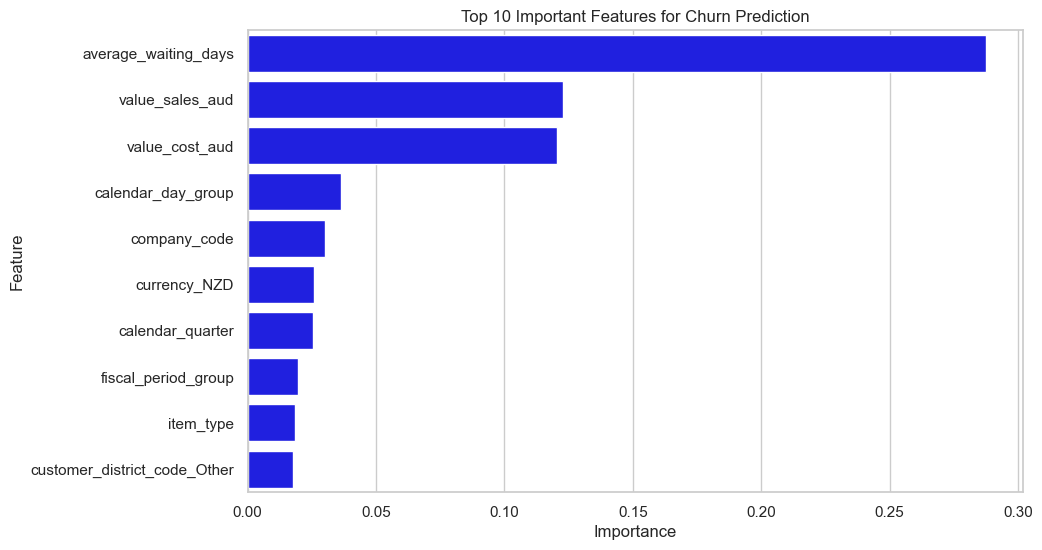

In [78]:
# Identify and plot feature importance
feature_importances = rf_model.feature_importances_

# Create a DataFrame for feature importance and sort by importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 10 important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), color='blue')
plt.title('Top 10 Important Features for Churn Prediction')
plt.show()

In [79]:
# Find the longest average waiting days
# Filter out negative values in 'average_waiting_days'
avg_waiting_days = churn_df[churn_df['average_waiting_days'] >= 0]

# Group by 'average_waiting_days' and calculate churn rate
churn_rates_waiting_days = avg_waiting_days.groupby('average_waiting_days')['churned'].agg(
    total_customers='count', 
    churned_customers='sum'
).reset_index()

# Calculate the churn rate
churn_rates_waiting_days['churn_rate'] = churn_rates_waiting_days['churned_customers'] / churn_rates_waiting_days['total_customers']

# Sort by churn rate and get the top 1
longest_avg_waiting_days = churn_rates_waiting_days.sort_values(by='churn_rate', ascending=False).head(1)

# Display the result
print(longest_avg_waiting_days[['average_waiting_days', 'churn_rate']])

      average_waiting_days  churn_rate
2410              6.521739         1.0


In [80]:
# Find the level of impact of each calendar group on churn rate
# Group by 'calendar_day_group' and calculate churn rate
churn_rates = churn_df.groupby('calendar_day_group')['churned'].agg(
    total_customers='count', 
    churned_customers='sum'
).reset_index()

# Calculate the churn rate
churn_rates['churn_rate'] = churn_rates['churned_customers'] / churn_rates['total_customers']

# Display the churn rates for all groups
print(churn_rates[['calendar_day_group', 'total_customers', 'churned_customers', 'churn_rate']])

   calendar_day_group  total_customers  churned_customers  churn_rate
0                   0           492968              26594    0.053947
1                   1           514868              28436    0.055230
2                   2           465492              28340    0.060882


In [81]:
# Find the level of impact of each calendar quarter group on churn rate
# Group by 'calendar_quarter' and calculate churn rate
churn_rates_quarter = churn_df.groupby('calendar_quarter')['churned'].agg(
    total_customers='count', 
    churned_customers='sum'
).reset_index()

# Calculate the churn rate
churn_rates_quarter['churn_rate'] = churn_rates_quarter['churned_customers'] / churn_rates_quarter['total_customers']

# Display the churn rates for all groups in calendar_quarter
print(churn_rates_quarter[['calendar_quarter', 'total_customers', 'churned_customers', 'churn_rate']])

   calendar_quarter  total_customers  churned_customers  churn_rate
0                 1           229375              14996    0.065378
1                 2           297698              17714    0.059503
2                 3           524151              28989    0.055307
3                 4           422104              21671    0.051340


In [82]:
# Find the level of each fiscal period group on churn rate
# Group by 'fiscal_period_group' and calculate churn rate
churn_rates_fiscal_period = churn_df.groupby('fiscal_period_group')['churned'].agg(
    total_customers='count', 
    churned_customers='sum'
).reset_index()

# Calculate the churn rate
churn_rates_fiscal_period['churn_rate'] = churn_rates_fiscal_period['churned_customers'] / churn_rates_fiscal_period['total_customers']

# Display the churn rates for all groups in fiscal_period_group
print(churn_rates_fiscal_period[['fiscal_period_group', 'total_customers', 'churned_customers', 'churn_rate']])

   fiscal_period_group  total_customers  churned_customers  churn_rate
0                    0           297698              17714    0.059503
1                    1           524151              28989    0.055307
2                    2           651479              36667    0.056283


In [83]:
# Find customer_district_code in "Other" group
# Function to get top N and "Other" categories for a column
def get_top_n_and_other_values(df, col, top_n=5):
    # Get the top N most frequent values
    top_values = df[col].value_counts().nlargest(top_n).index.tolist()
    
    # Get all unique values
    all_values = df[col].unique()
    
    # Identify the values that go into "Other"
    other_values = [val for val in all_values if val not in top_values]
    
    # Return top values and other values
    return top_values, other_values

# Get top 5 and "Other" values for 'customer_district_code'
top_values, other_values = get_top_n_and_other_values(df_combined, 'customer_district_name', top_n=5)

# Print the results
print(f"Top 5 most frequent values in 'customer_district_code': {top_values}")
print(f"Values grouped into 'Other' for 'customer_district_code': {other_values}")

Top 5 most frequent values in 'customer_district_code': ['Melbourne', 'Sydney', 'Brisbane', 'Adelaide', 'Perth']
Values grouped into 'Other' for 'customer_district_code': ['Townsville', 'Tasmania', 'ACT/Riverina', 'Intercompany Sales', 'Head Office Sales', 'Darwin', 'South Island - NZ', 'Central Region - NZ', 'Northern Region - NZ', 'Inlite - NZ', 'Head Office - NZ']
